# Part 2: Tiền xử lý dữ liệu dạng bảng (Tabular Data Preprocessing)

## 1. Mô tả Dataset

### 1.1 Dataset đã chọn
**Tên dataset:** 

**Nguồn:** [Car resale data - 2023](https://www.kaggle.com/datasets/rahulmenon1758/car-resale-prices)

**Kích thước:** 
- Số lượng records: 17446 rows
- Số lượng attributes: 15
- Dung lượng file: 2.82 MB

**Mô tả:**
* full_name: Name of the car along with model
* resale_price: Resale price of the car
* registered_year: Year the car was registered
* engine_capacity: Engine Displacement of car (cc)
* insurance: Type of insurance made available for the car (if any)
* transmission_type: Transmission type of the car
* kms_driven: Total kilometers the car was driven for
* owner_type: Number of owners who previously owned the car
* fuel_type: Type of fuel the car uses
* max_power: Maximum power of the car (bhp)
* seats: Number of seats the car has
* mileage: Mileage of the car
* body_type: Body configuration of the car
* city: City in India the car is sold in

**Target variable:** resale_price

## 2. Import Libraries

In [94]:
# Thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# Thư viện preprocessing
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    RFE
)
from sklearn.ensemble import RandomForestClassifier

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 8)

## 3. Load and Explore Dataset

**Giải thích:** Tải dữ liệu và khám phá cấu trúc ban đầu.

In [95]:
current_path = os.getcwd()

parrent_path = os.path.dirname(current_path)
data_dir = os.path.join(parrent_path, 'data', 'tabular', 'raw', 'car_resale_prices.csv')
print(data_dir)

d:\Đại học\Kỳ 8\Class - Data mining\Lab\Lab 1\hcmus-data-mining--preprocessing\data\tabular\raw\car_resale_prices.csv


In [96]:
# TODO: Load dataset
df = pd.read_csv(data_dir)
print(f"Shape: {df.shape}")
df.head(5)

Shape: (17446, 15)


,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


### 3.1 Basic Information

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  object 
 2   resale_price       17446 non-null  object 
 3   registered_year    17377 non-null  object 
 4   engine_capacity    17432 non-null  object 
 5   insurance          17439 non-null  object 
 6   transmission_type  17446 non-null  object 
 7   kms_driven         17443 non-null  object 
 8   owner_type         17401 non-null  object 
 9   fuel_type          17446 non-null  object 
 10  max_power          17344 non-null  object 
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  object 
 13  body_type          17446 non-null  object 
 14  city               17446 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 2.0+ MB


In [98]:
df.describe()

,Unnamed: 0,seats
count,17446.000000,17436.000000
mean,8722.500000,5.205494
std,5036.370734,0.669321
min,0.000000,2.000000
25%,4361.250000,5.000000
50%,8722.500000,5.000000
75%,13083.750000,5.000000
max,17445.000000,14.000000


In [99]:
df.isnull().sum()

Unnamed: 0             0
full_name              0
resale_price           0
registered_year       69
engine_capacity       14
insurance              7
transmission_type      0
kms_driven             3
owner_type            45
fuel_type              0
max_power            102
seats                 10
mileage              508
body_type              0
city                   0
dtype: int64

In [100]:
df.columns

Index(['Unnamed: 0', 'full_name', 'resale_price', 'registered_year',
       'engine_capacity', 'insurance', 'transmission_type', 'kms_driven',
       'owner_type', 'fuel_type', 'max_power', 'seats', 'mileage', 'body_type',
       'city'],
      dtype='object')

Nhận xét: 
* Cột dư Unnamed
* Năm sản suất ở trong full_name
* Các cột số đang ở dạng string (object):
	- resale price là dạng text có ký tự
	- engine_capacity có ký tự cc
	- kms_driven dư đơn vị (Kms) -> bỏ ký tự Kms 
	- max_power dư đơn vị bhd,... -> chuyển thành cùng đơn vị kW
	- mileage có dư đơn vị (kmpl)
	- year đang ở object -> integer (int32, int64) (or date (full date))

### 3.2 Clean data

In [101]:
# Helper function
def get_unit(col_name):
    if pd.isna(col_name):
        return None
    

    col_name = str(col_name).strip().replace(',', '') # Chuyển về chuỗi và loại bỏ khoảng trắng thừa
    match = re.search(r"(\d+\.?\d*)", col_name) # Tìm phần số đầu tiên trong chuỗi (ví dụ: '83.1' trong '83.1bhp')
    
    if match:
        unit = col_name[match.end():].strip()
        return unit if unit else "No Unit" # Trả về đơn vị nếu tìm thấy, ngược lại trả về 'No Unit'
    
    return "Unknown Format"

Bỏ cột không cần thiết

In [102]:
df_cleaned = df.drop(columns=['Unnamed: 0'])

clean_price: 
* Bỏ ký tự '₹' và dấu phẩy ','
* Bỏ chữ 'Lakh', chuyển thành số và nhân 100,000
* Bỏ chữ 'Crore', chuyển thành số và nhân 10,000,000

In [103]:
def clean_price(price_str):
    if pd.isna(price_str):
        return None

    clean_str = price_str.replace('₹', '').replace(',', '').strip()
    
    if 'Lakh' in clean_str:
        return float(clean_str.replace('Lakh', '').strip()) * 100000
    elif 'Crore' in clean_str:
        return float(clean_str.replace('Crore', '').strip()) * 10000000
    else:
        return float(clean_str)
    
df_cleaned['cleaned_resale_price'] = df_cleaned['resale_price'].apply(clean_price)
df_cleaned.head()

,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0


engine_capacity bỏ ký tự đơn vị cc

In [104]:
def clean_engine_capacity(engine_str):
    if pd.isna(engine_str):
        return None
    clean_str = engine_str.replace('cc', '').strip()
    return float(clean_str)
df_cleaned['cleaned_engine_capacity'] = df_cleaned['engine_capacity'].apply(clean_engine_capacity)
df_cleaned.head()

,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price,cleaned_engine_capacity
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,1197.0
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,2179.0
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0,1086.0


In [105]:
unique_units = df['kms_driven'].apply(get_unit).unique()
print("kms_driven unique units: ", unique_units)
def clean_kms(kms_str):
    if pd.isna(kms_str):
        return None
    kms_str = str(kms_str).replace(',', '').replace(' Kms', '').replace(' kms', '').strip()
    try:
        return float(kms_str)
    except ValueError:
        return None
df_cleaned['cleaned_kms_driven'] = df_cleaned['kms_driven'].apply(clean_kms)
df_cleaned.head()

kms_driven unique units:  ['Kms' None]


,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price,cleaned_engine_capacity,cleaned_kms_driven
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,1197.0,40000.0
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,2179.0,70000.0
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0,1086.0,80000.0


max_power: Đổi đơn vị của max_power ra dùng chung bhp

In [106]:
# Lấy các giá trị unique để xem có những loại đơn vị nào
unique_units = df['max_power'].apply(get_unit).unique()
print("Các đơn vị trong cột max_power:", unique_units)

def convert_power_to_kw(value):
    if pd.isna(value):
        return None
    s = str(value).lower().strip()
    
    if s.startswith('/'):
        return None

    match = re.search(r"(\d+(\.\d+)?)", s)
    if not match:
        return None
    number = float(match.group(1))
    if number > 2000:
        return None

    if 'kw' in s:
        return number   
    
    # Trường hợp đơn vị là PS
    elif 'ps' in s:
        return round(number * 0.7355, 2)
    else:
        return round(number * 0.7457, 2) # bhp

df_cleaned['cleaned_max_power'] = df_cleaned['max_power'].apply(convert_power_to_kw)
df_cleaned.head()

Các đơn vị trong cột max_power: ['bhp' 'PS' 'No Unit' 'PS at 5400 rpm' None 'bhp (86.7kw)'
 'PS at 4000 rpm' 'kW' 'PS at 6600 rpm' 'PS at 5200 rpm' 'ps' 'kWbhp'
 'bhp5500-6100bhp' 'PS at 4500 rpm' 'Bhp' 'bhp at 3800 rpm' '(66)'
 'PS at 5250 rpm' 'PS at 5500 rpm' 'PS at 4000rpm' 'bhp3600-4200rpm'
 'PS at 5500 RPM' 'bhp at 5400 rpm' 'HP at 3200 rpm' '/4000-6000'
 'PS at 4000 RPM' 'BHP' 'bhp3750rpm' 'PS at 5500rpm' 'ps 3850 rpm'
 'kW at 6300 rpm' 'PS at 6000rpm' '[224] at 3800' '(90) / 4000' 'Bhpbhp'
 '(150)/5700' 'hp' 'bhp at 4000 rpm' 'kw']


,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price,cleaned_engine_capacity,cleaned_kms_driven,cleaned_max_power
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,1197.0,40000.0,61.97
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,2179.0,70000.0,114.73
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0,1086.0,80000.0,50.74


mileage (mức tiêu hao nhiên liệu) có 2 đơn v: kmpl và km/kg -> chuyển thành chung đơn vị + xóa string đơn vị -> float

In [107]:
unique_units = df['mileage'].apply(get_unit).unique()
print("mileage unique units: ", unique_units)

# Xử lý chuyển về cùng đơn vị km/l và xóa tên đơn vị chuyển thành float
def clean_mileage(mileage_str):
    if pd.isna(mileage_str):
        return None
    
    s = str(mileage_str).lower().strip()
    match = re.search(r"(\d+(\.\d+)?)", s)
    if not match:
        return None
    
    number = float(match.group(1))
    if 'km/kg' in s:
        
        return round(number * 2.653, 2)  # 1 km/kg ≈ 2.653 km/l
    else:
        return number  # Giữ nguyên nếu đã là km/l
    
df_cleaned['cleaned_mileage'] = df_cleaned['mileage'].apply(clean_mileage)
df_cleaned.head()

mileage unique units:  ['kmpl' None 'km/kg']


,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price,cleaned_engine_capacity,cleaned_kms_driven,cleaned_max_power,cleaned_mileage
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,1197.0,40000.0,61.97,21.40
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,2179.0,70000.0,114.73,17.60
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0,1086.0,80000.0,50.74,19.81


In [108]:
def clean_year(year_str):
    if pd.isna(year_str):
        return None
    # Tìm chuỗi 4 chữ số liên tiếp (năm)
    match = re.search(r'\d{4}', str(year_str))
    if match:
        return int(match.group(0))
    return None
df_cleaned['cleaned_registered_year'] = df_cleaned['registered_year'].apply(clean_year)
df_cleaned.head()

,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city,cleaned_resale_price,cleaned_engine_capacity,cleaned_kms_driven,cleaned_max_power,cleaned_mileage,cleaned_registered_year
0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra,545000.0,1197.0,40000.0,61.97,21.40,2017.0
1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra,1000000.0,2179.0,70000.0,114.73,17.60,2018.0
2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra,160000.0,1086.0,80000.0,50.74,19.81,2009.0


In [109]:
final_cleaned_df = df_cleaned.copy().drop(columns=['resale_price', 'registered_year', 'engine_capacity', 'kms_driven', 'max_power', 'mileage'])
final_cleaned_df.rename(columns={
    'cleaned_resale_price': 'resale_price',
    'cleaned_engine_capacity': 'engine_capacity',
    'cleaned_kms_driven': 'kms_driven',
    'cleaned_max_power': 'max_power',
    'cleaned_mileage': 'mileage',
    'cleaned_registered_year': 'registered_year'
}, inplace=True)
final_cleaned_df.head(10)

,full_name,insurance,transmission_type,owner_type,fuel_type,seats,body_type,city,resale_price,engine_capacity,kms_driven,max_power,mileage,registered_year
0,2017 Maruti Baleno 1.2 Alpha,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,545000.0,1197.0,40000.0,61.97,21.40,2017.0
1,2018 Tata Hexa XTA,Third Party insurance,Automatic,First Owner,Diesel,7.0,MUV,Agra,1000000.0,2179.0,70000.0,114.73,17.60,2018.0
2,2015 Maruti Swift Dzire VXI,Third Party insurance,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
3,2015 Maruti Swift Dzire VXI,Third Party insurance,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
4,2009 Hyundai i10 Magna 1.1,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,160000.0,1086.0,80000.0,50.74,19.81,2009.0
5,2015 Hyundai i20 Active 1.2,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,470000.0,1197.0,70000.0,61.04,17.19,2015.0
6,2017 Tata Tiago 1.05 Revotorq XZ,Third Party insurance,Manual,First Owner,Diesel,5.0,Hatchback,Agra,360000.0,1047.0,120000.0,51.45,27.28,2017.0
7,2010 Hyundai i10 Magna 1.1,Third Party insurance,Manual,Second Owner,Petrol,5.0,Hatchback,Agra,200000.0,1086.0,60000.0,50.74,19.81,2010.0
8,2016 Maruti Eeco 7 Seater Standard BSIV,Third Party insurance,Manual,First Owner,Petrol,7.0,Minivans,Agra,370000.0,1196.0,20000.0,54.44,15.37,2016.0
9,2009 Hyundai Santro Xing GL,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,120000.0,1086.0,30000.0,46.23,NaN,2009.0


In [110]:
# chuẩn hóa trong insurance "Third Party insurance" thành Third Party
final_cleaned_df['insurance'] = final_cleaned_df['insurance'].str.replace('Third Party insurance', 'Third Party', regex=False) 

Lưu tạm vào cleaned data

In [111]:
# Lưu vào file CSV
output_dir = os.path.join(parrent_path, 'data', 'tabular', 'cleaned', 'car_resale_prices_cleaned.csv')
final_cleaned_df.to_csv(output_dir, index=False)

### 3.3 Data Types and Categories

In [112]:
# Identify numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (7): ['seats', 'cleaned_resale_price', 'cleaned_engine_capacity', 'cleaned_kms_driven', 'cleaned_max_power', 'cleaned_mileage', 'cleaned_registered_year']

Categorical columns (13): ['full_name', 'resale_price', 'registered_year', 'engine_capacity', 'insurance', 'transmission_type', 'kms_driven', 'owner_type', 'fuel_type', 'max_power', 'mileage', 'body_type', 'city']


### 3.4 Bảng mô tả dữ liệu

| Tên cột             | Kiểu dữ liệu | Mô tả                                                       | Ví dụ                              |
| ------------------- | ------------ | ----------------------------------------------------------- | ---------------------------------- |
| `full_name`         | string       | Tên đầy đủ của xe (năm sản xuất + hãng + model + phiên bản) | `2017 Maruti Baleno 1.2 Alpha`     |
| `insurance`         | string       | Loại bảo hiểm xe                                            | `Third Party`            |
| `transmission_type` | string       | Loại hộp số                                                 | `Manual`, `Automatic`              |
| `owner_type`        | string       | Tình trạng chủ sở hữu trước đó                              | `First Owner`, `Second Owner`      |
| `fuel_type`         | string       | Loại nhiên liệu                                             | `Petrol`, `Diesel`, `CNG`          |
| `seats`             | float        | Số chỗ ngồi của xe                                          | `5`                                |
| `body_type`         | string       | Kiểu thân xe                                                | `Hatchback`, `Sedan`, `SUV`, `MUV` |
| `city`              | string       | Thành phố đăng bán xe                                       | `Agra`                             |
| `resale_price`      | float        | Giá bán lại của xe (đơn vị: rupee (Ấn độ))                  | `545000`                           |
| `engine_capacity`   | float        | Dung tích động cơ (cc)                                      | `1197`                             |
| `kms_driven`        | float        | Số km xe đã chạy  (đơn vị chung: km/l)                      | `40000`                            |
| `max_power`         | float        | Công suất tối đa (bhp)                                      | `61.97`                            |
| `mileage`           | float        | Mức tiêu hao nhiên liệu (km/l)                              | `21.4`                             |
| `registered_year`   | float        | Năm đăng ký xe                                              | `2017`                             |


### 3.5 EDA - Explore Data Analysis

#### 3.5.0. Tổng quan dữ liệu & Kiểm tra giá trị thiếu (Missing Values)

In [113]:
eda_df = final_cleaned_df.copy()

In [114]:
eda_df.shape

(17446, 14)

In [115]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_name          17446 non-null  object 
 1   insurance          17439 non-null  object 
 2   transmission_type  17446 non-null  object 
 3   owner_type         17401 non-null  object 
 4   fuel_type          17446 non-null  object 
 5   seats              17436 non-null  float64
 6   body_type          17446 non-null  object 
 7   city               17446 non-null  object 
 8   resale_price       17446 non-null  float64
 9   engine_capacity    17432 non-null  float64
 10  kms_driven         17443 non-null  float64
 11  max_power          17344 non-null  float64
 12  mileage            16938 non-null  float64
 13  registered_year    17377 non-null  float64
dtypes: float64(7), object(7)
memory usage: 1.9+ MB


In [116]:
eda_df.isna().sum()

full_name              0
insurance              7
transmission_type      0
owner_type            45
fuel_type              0
seats                 10
body_type              0
city                   0
resale_price           0
engine_capacity       14
kms_driven             3
max_power            102
mileage              508
registered_year       69
dtype: int64

Nhận xét: Có những attributes có missing value
* insurance
* owner_type            
* seats                 
* engine_capacity
* kms_driven
* max_power
* mileage
* registered_year

#### 3.5.1. Phân tích dữ liệu 1 biến
1. Biến continuous
    * Phân phối
    * Outlier, Noise

In [117]:
# Helper function for univariate analysis numerical columns
def univariate_numerical_analysis(df, columns, bins=50):
    if isinstance(columns, str):
        columns = [columns]

    n_rows = len(columns)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows), squeeze=False)

    for i, column in enumerate(columns):
        series = df[column].dropna()

        # Histogram
        sns.histplot(series, kde=True, bins=bins, ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {column}')
        axes[i, 0].set_xlabel(column)
        axes[i, 0].set_ylabel('Frequency')

        # Boxplot
        sns.boxplot(x=series, ax=axes[i, 1])
        axes[i, 1].set_title(f'Boxplot of {column}')
        axes[i, 1].set_xlabel(column)

    plt.tight_layout()
    plt.show()


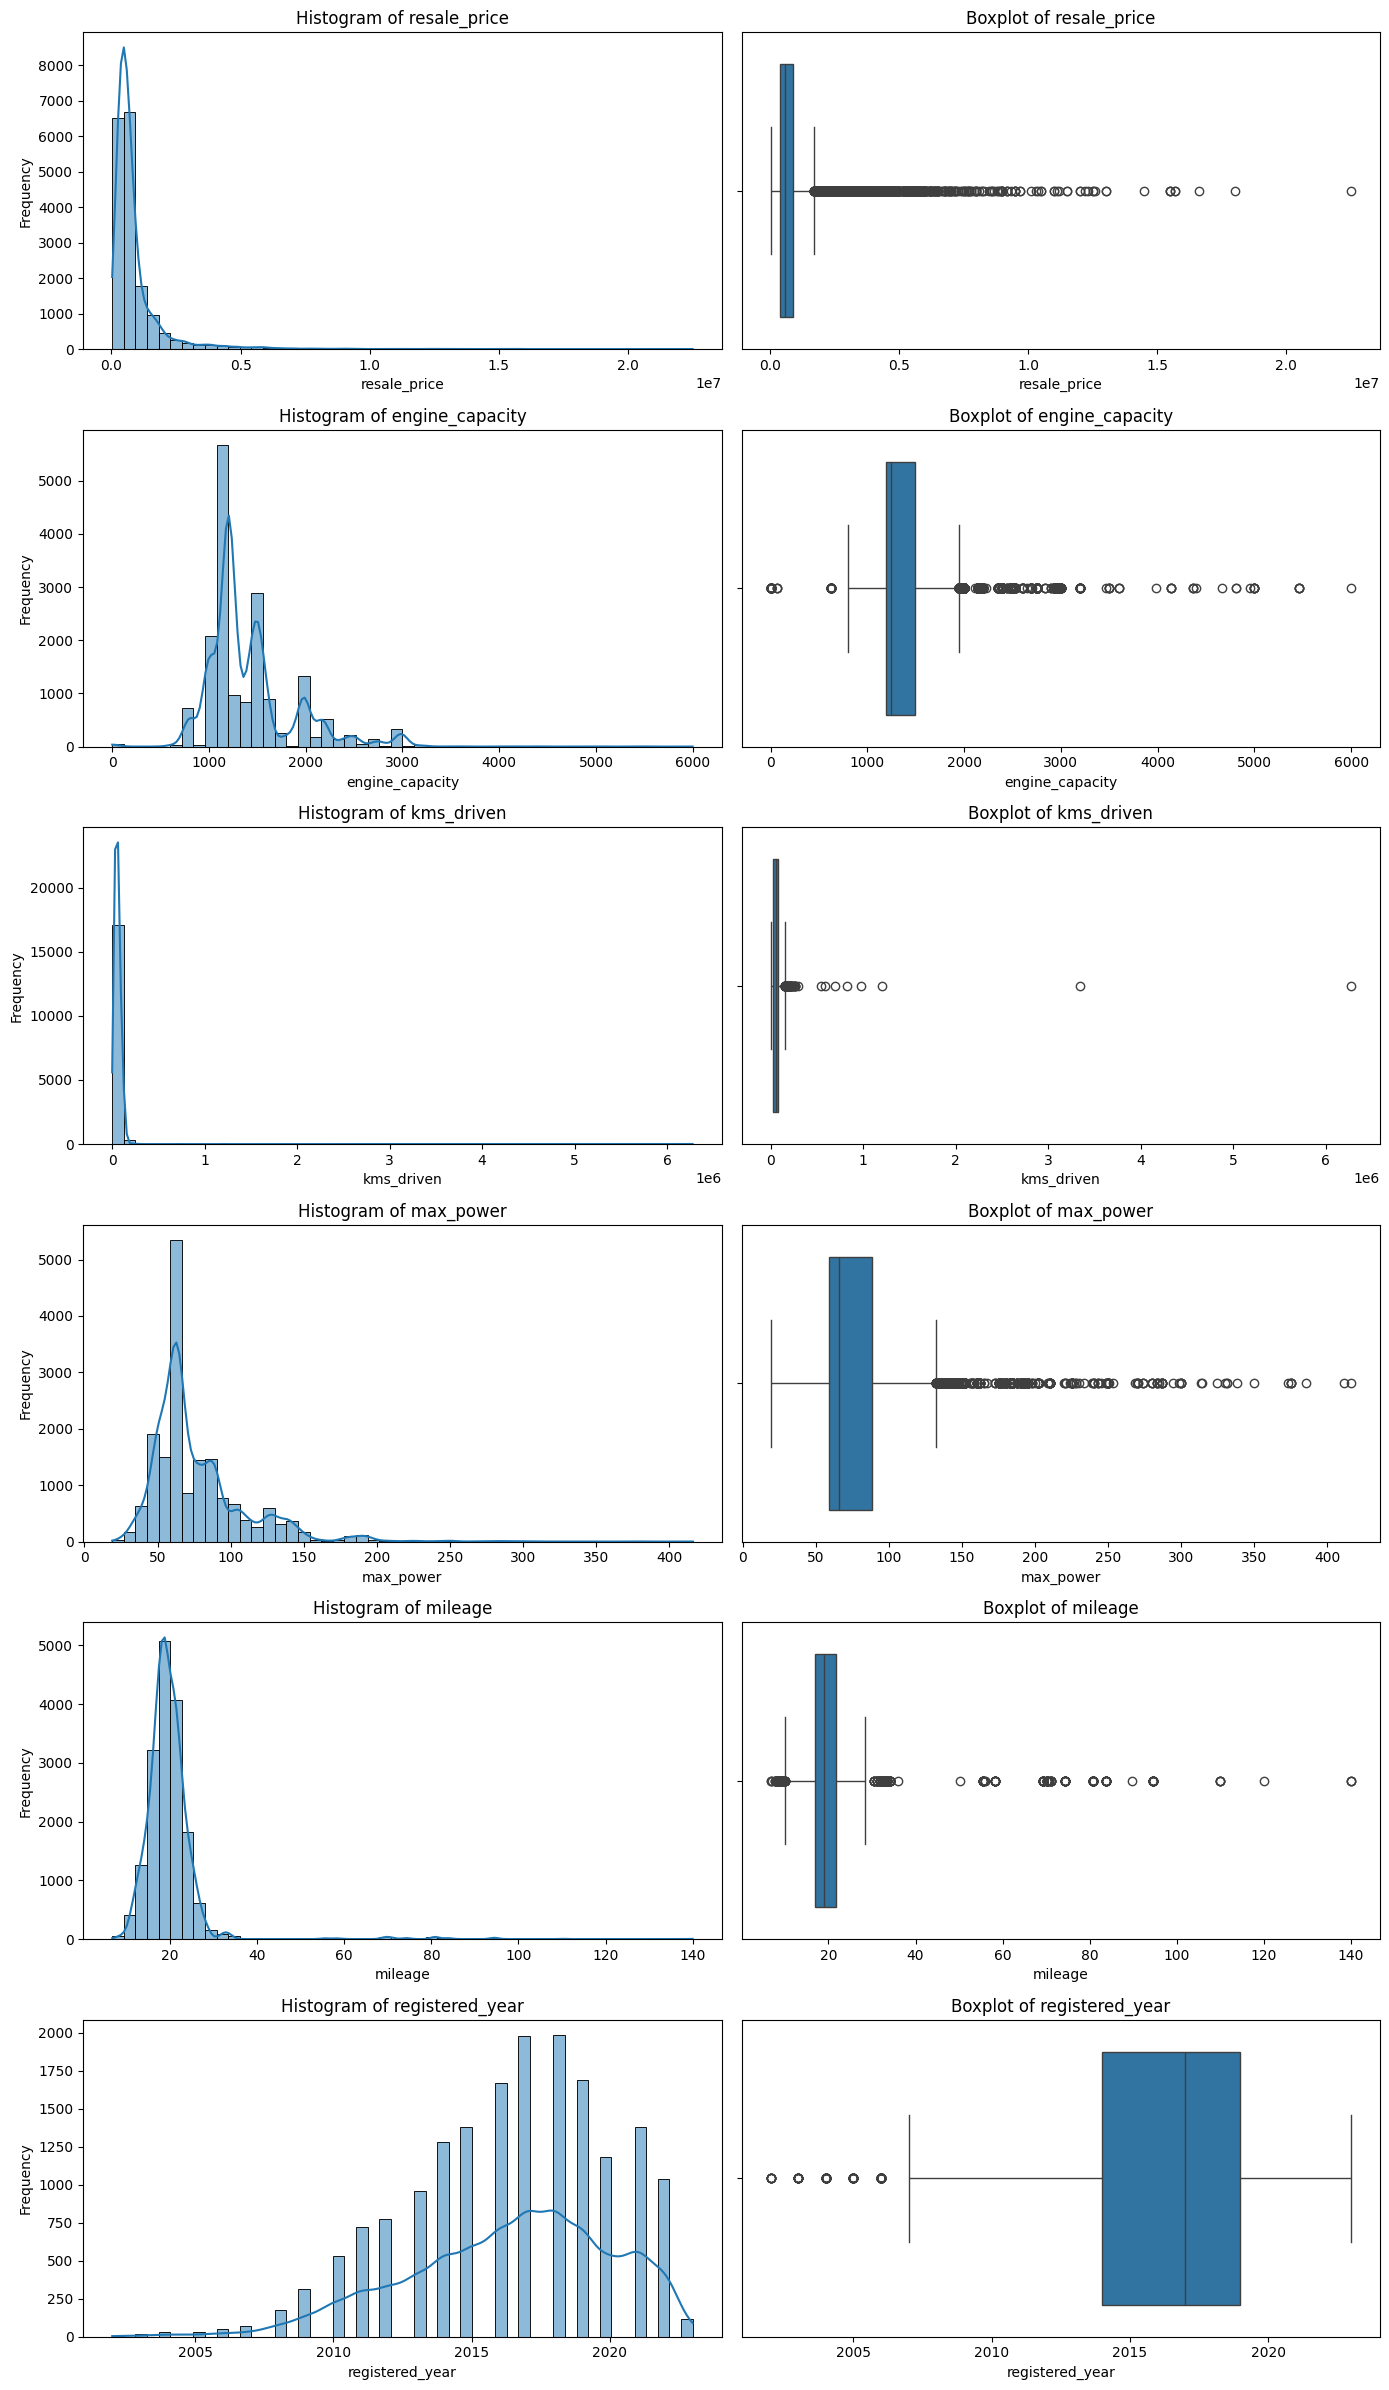

In [118]:
num_cols = ['resale_price', 'engine_capacity', 'kms_driven', 'max_power', 'mileage', 'registered_year']
univariate_numerical_analysis(eda_df, num_cols)

2. Biến category
    * Phân bố (bar chart, pie chart hoặc chart khác)

In [119]:
# helper function for univariate analysis categorical columns
def univariate_categorical_analysis(df, columns):
    if isinstance(columns, str):
        columns = [columns]

    n_rows = len(columns)
    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 4 * n_rows), squeeze=False)

    for i, column in enumerate(columns):
        ax = axes[i, 0]

        # Bar plot và gắn thêm số lượng ở mỗi thanh
        sns.countplot(y=df[column], order=df[column].value_counts().index, ax=ax)
        for p in ax.patches:
            width = p.get_width()
            ax.text(width + 1, p.get_y() + p.get_height() / 2, int(width), va='center')
        ax.set_title(f'Count Plot of {column}')
        ax.set_xlabel('Count')
        ax.set_ylabel(column)

    plt.tight_layout()
    plt.show()

In [120]:
cat_cols = [
    'insurance',
    'transmission_type',
    'owner_type',
    'fuel_type',
    'body_type',
    'city',
    'seats'
]

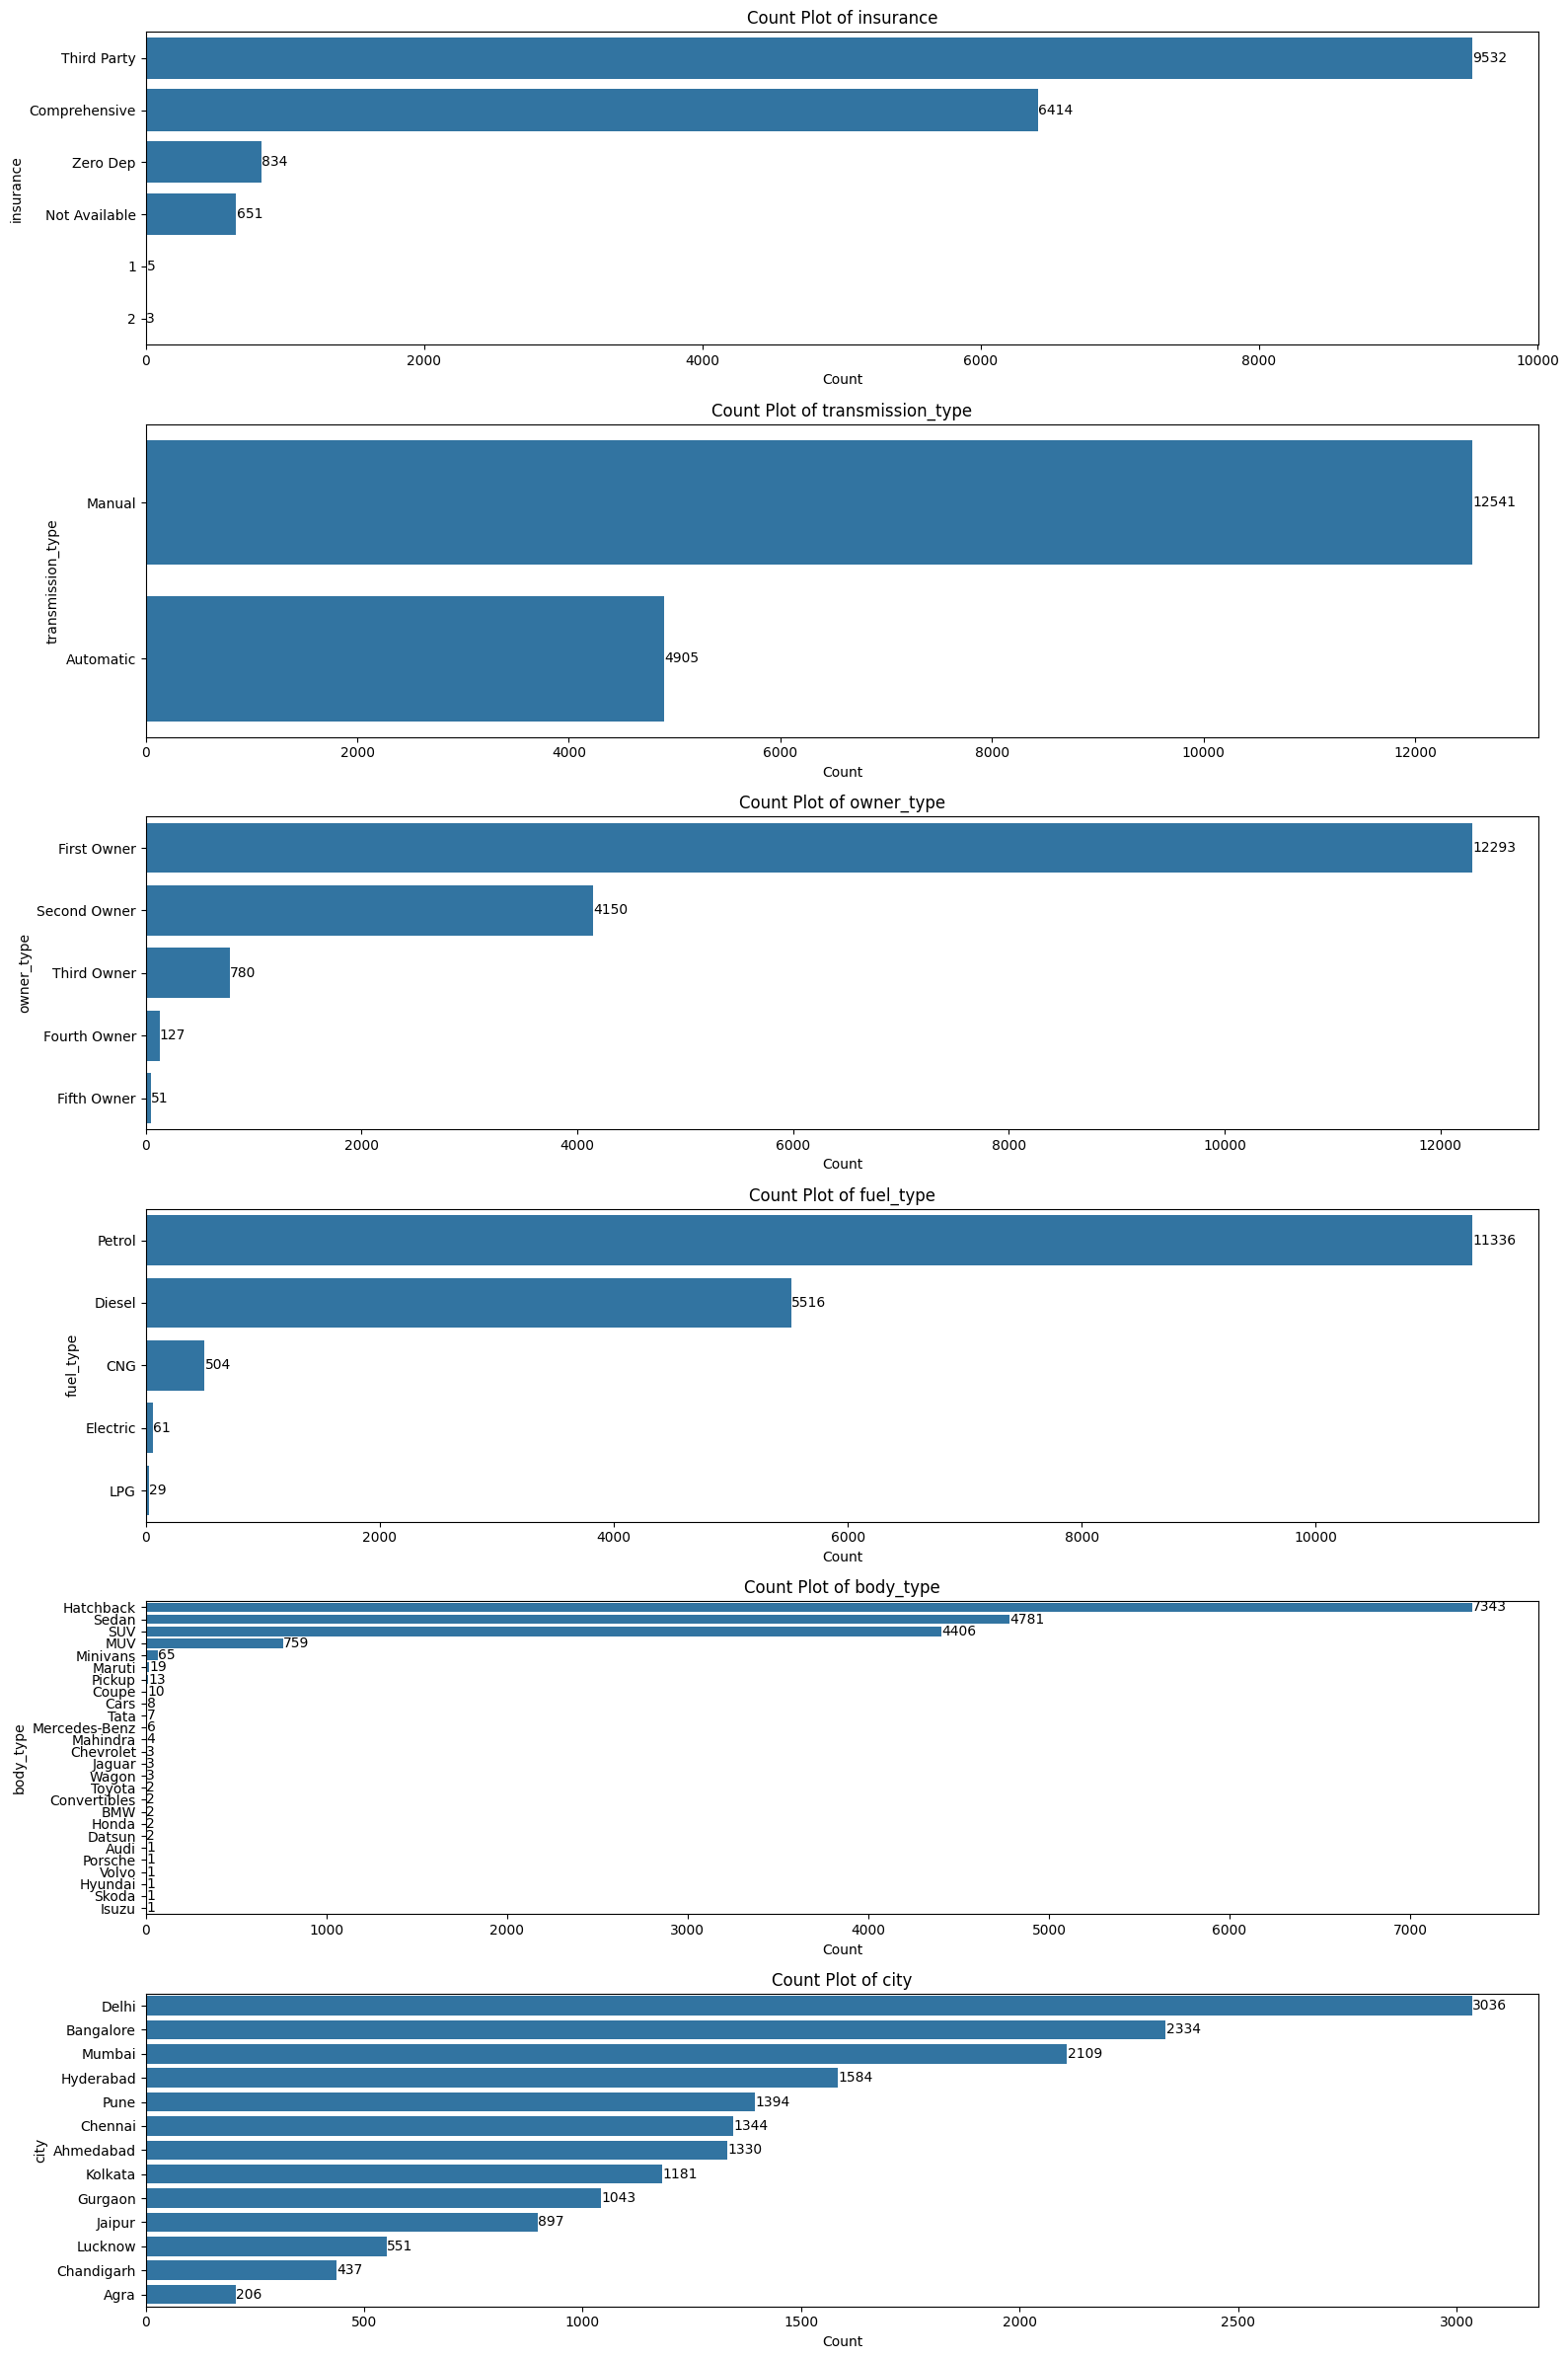

In [121]:
# Vẽ 6 cột categorical trong cùng 1 ảnh (theo chiều dọc)
univariate_categorical_analysis(eda_df, cat_cols[:6])

#### 3.5.2. Phân tích dữ liệu tương quan 2 biến


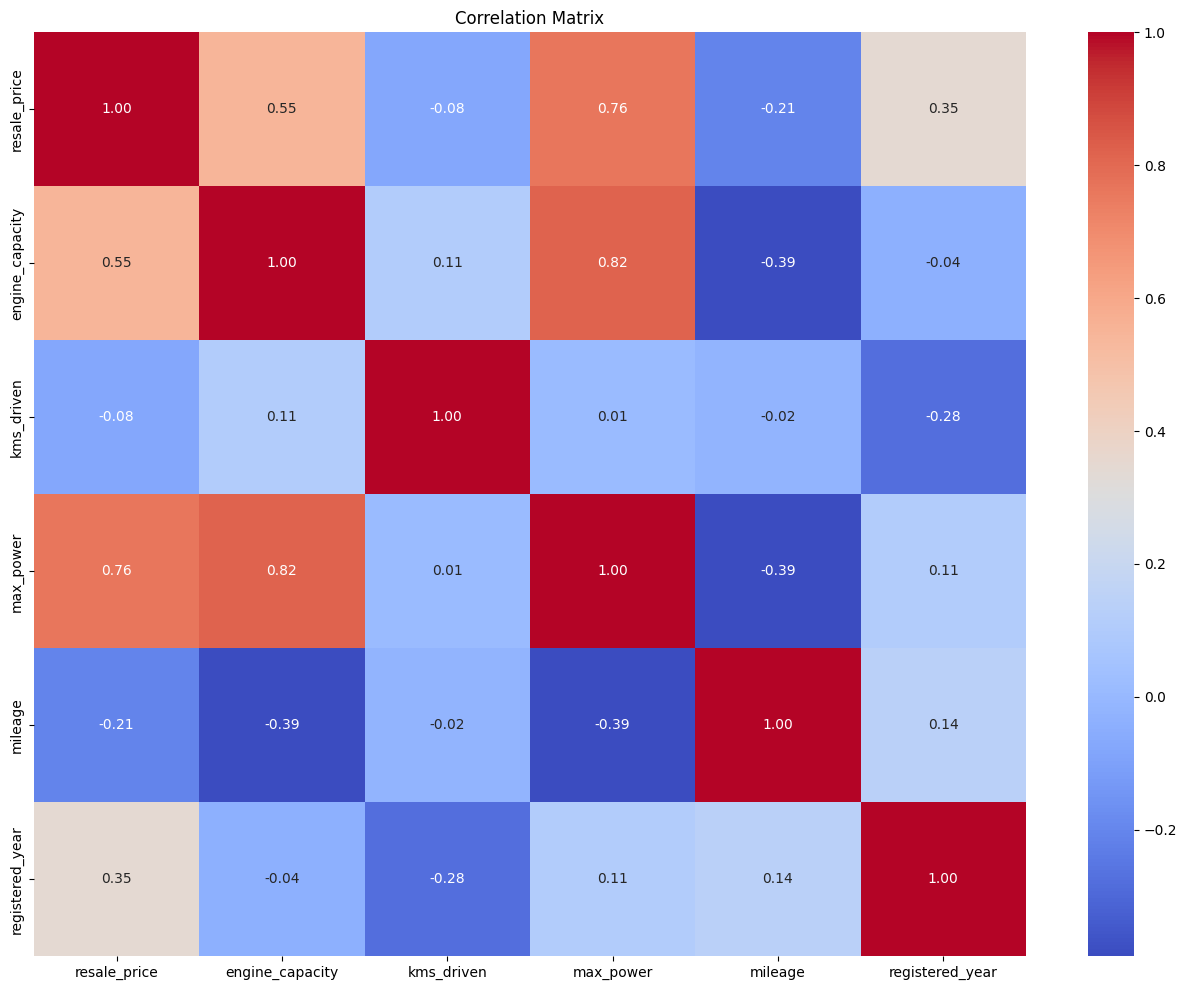

In [122]:
plt.figure(figsize=(16, 12))
corr = eda_df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

---

## 4. Handling Missing Values

### 4.1 Rationale

**Các loại missing data:**
1. **MCAR (Missing Completely At Random):** 
* Định nghĩa: Lỗi thiếu dữ liệu hoàn toàn ngẫu nhiên hay xác suất một giá trị bị thiếu không phụ thuộc vào bất kỳ biến nào, kể cả chính nó.
$$ P(Missing∣X,Y) = P(Missing) $$
* Xảy ra khi:
    * Có yếu tố ngoại sinh, kỹ thuật, ngẫu nhiên:
        * Lỗi thiết bị đo làm mất bản ghi ngẫu nhiên.
        * Lỗi nhập liệu, mất file tạm thời.
        * Một số bảng hỏi bị thất lạc ngẫu nhiên trong quá trình thu thập.
        * Hệ thống IT ghi log bị gián đoạn trong vài phút.
        * Ví dụ: Trong khảo sát 1.000 người, 5% bảng hỏi bị thất lạc do lỗi in ấn – không liên quan đến tuổi, giới tính, thu nhập… → có thể xem là MCAR.
    * Dấu hiệu và cách thức nhận biết MCAR:
        * So sánh nhóm có thiếu vs không thiếu:
            * Chia dữ liệu thành 2 nhóm: có missing và không missing.
            * So sánh trung bình/tỷ lệ các biến quan sát được.
            * Nếu không có khác biệt có ý nghĩa thống kê, MCAR có khả năng đúng.
        * Kiểm định Little’s MCAR test
            * Kiểm định giả thuyết:
                * H0: Dữ liệu là MCAR
                * Nếu p-value > 0.05 → không bác bỏ H0 → có thể là MCAR
        * Phân tích mô hình logistic
            * Dùng biến nhị phân (1 = thiếu, 0 = không thiếu) làm biến phụ thuộc.       
* Phương pháp xử lý MCAR:
    * Listwise Deletion (Complete Case Analysis): Loại bỏ toàn bộ dòng có missing.
    * Pairwise Deletion: Dùng tối đa dữ liệu sẵn có cho từng phân tích. 
    * Mean/Median Imputation: Thay bằng trung bình/trung vị.
    * Multiple Imputation: Tạo nhiều bộ dữ liệu thay thế.
    * Maximum Likelihood: Ước lượng trực tiếp từ dữ liệu chưa hoàn chỉnh.


2. **MAR (Missing At Random):** 
* MAR là cơ chế thiếu dữ liệu khi xác suất bị thiếu phụ thuộc vào các biến quan sát được, nhưng không phụ thuộc vào chính giá trị bị thiếu, sau khi đã kiểm soát các biến quan sát đó.
* MAR xảy ra khi:
    $$P(R∣Y_{obs​},Y_{mis​})=P(R∣Y{obs​})$$
    Trong đó: 
    * $Y_{obs​}$: dữ liệu quan sát được
    * $Y_{mis}$: dữ liệu thiếu
    * $R$: biến chỉ báo thiếu dữ liệu
* Ví dụ MAR: Một khảo sát thu nhập.
    * Nam giới ít trả lời câu hỏi về thu nhập hơn nữ.
    * Nhưng trong mỗi nhóm giới tính, việc có trả lời hay không không phụ thuộc vào mức thu nhập thực tế.
    → Xác suất thiếu phụ thuộc vào giới tính (biến quan sát được), không phụ thuộc vào thu nhập thật sự
* Dấu hiệu phát hiện MAR: 
    * So sánh nhóm có missing vs không missing: Nếu thấy sự khác biệt theo biến quan sát được (tuổi, giới, thu nhập…) → Có khả năng MAR.
    * Little’s MCAR test
    * Logistic regression dự đoán missing
* Phương pháp xử lý MAR:
    * Multiple Imputation
        * Tạo nhiều bộ dữ liệu thay thế.
        * Dựa trên các biến quan sát được để dự đoán giá trị thiếu.
        * Kết quả được gộp lại (Rubin’s Rules).
        * Hoạt động tốt khi MAR đúng.
    * KNN imputation
    * Model-based approaches: regression imputation.
    * Maximum Likelihood (FIML): Ước lượng trực tiếp từ dữ liệu không hoàn chỉnh. (SEM, CFA)
    * Không nên dùng Mean imputation hay Listwise deletion (khi tỷ lệ missing đáng kể)

3. **MNAR (Missing Not At Random):**
* MNAR (Missing Not At Random) là cơ chế thiếu dữ liệu khi: Xác suất một giá trị bị thiếu phụ thuộc vào chính giá trị bị thiếu đó, ngay cả khi đã kiểm soát các biến quan sát được.
* Dữ liệu bị thiếu không phải ngẫu nhiên, và lý do thiếu liên quan đến bản thân giá trị thật sự của biến đó.
* MNAR xảy ra khi:
    * Khi giá trị “nhạy cảm”, liên quan đến cá nhân hóa, có cơ chế tự chọn (self-selection bias)
        * Giá trị càng cao hoặc càng thấp thì xác suất thiếu càng lớn -> bias (thu nhập, cân nặng, ...)
    * Khi kết quả xấu làm người tham gia rút lui
* Dấu hiệu phát hiện MNAR:
    * Mô hình MAR không giải thích được missingness
        * Logistic regression dự đoán missing ~ các biến quan sát
        * Nếu R² rất thấp → có thể missing phụ thuộc vào chính biến đó
    * Phân phối biến bị thiếu lệch rõ rệt: So sánh nhóm có dữ liệu và nhóm thiếu, nếu phân phối khác biệt lớn → nghi ngờ MNAR
    * Có lý do lý thuyết/logic thực tế (kiến thức chuyên môn quan trọng hơn test thống kê)
* Lưu ý: MNAR nguy hiểm vì
    * Ước lượng bị bias nghiêm trọng
    * Imputation chuẩn (Mean/MI/MAR-based) sẽ sai
    * Kết luận nghiên cứu có thể lệch hệ thống
* Phương pháp xử lý MNAR: không có cơ chế xử lý cố định, hoàn hảo
    * Sensitivity Analysis: Thử nhiều giả định khác nhau về giá trị bị thiếu
    * Selection Model
    * Pattern-Mixture Model: Chia dữ liệu theo pattern missing (complete, missing)
    * Heckman Selection Model: Dùng khi có bias do self-selection (kinh tế lượng)
        1. Phương trình chọn mẫu
        2. Phương trình kết quả
        3. Hiệu chỉnh bằng Inverse Mills Ratio
    * Bayesian Modeling:
        * Đặt prior cho phân phối giá trị bị thiếu
        * Mô hình joint distribution

### 4.2 Identify Missing Patterns

In [123]:
eda_df.isna().sum()

full_name              0
insurance              7
transmission_type      0
owner_type            45
fuel_type              0
seats                 10
body_type              0
city                   0
resale_price           0
engine_capacity       14
kms_driven             3
max_power            102
mileage              508
registered_year       69
dtype: int64

Nhận xét: Có những attributes có missing value
* insurance
* owner_type            
* seats                 
* engine_capacity
* kms_driven
* max_power
* mileage
* registered_year

#### 4.2.1. Method 1: Visualization 

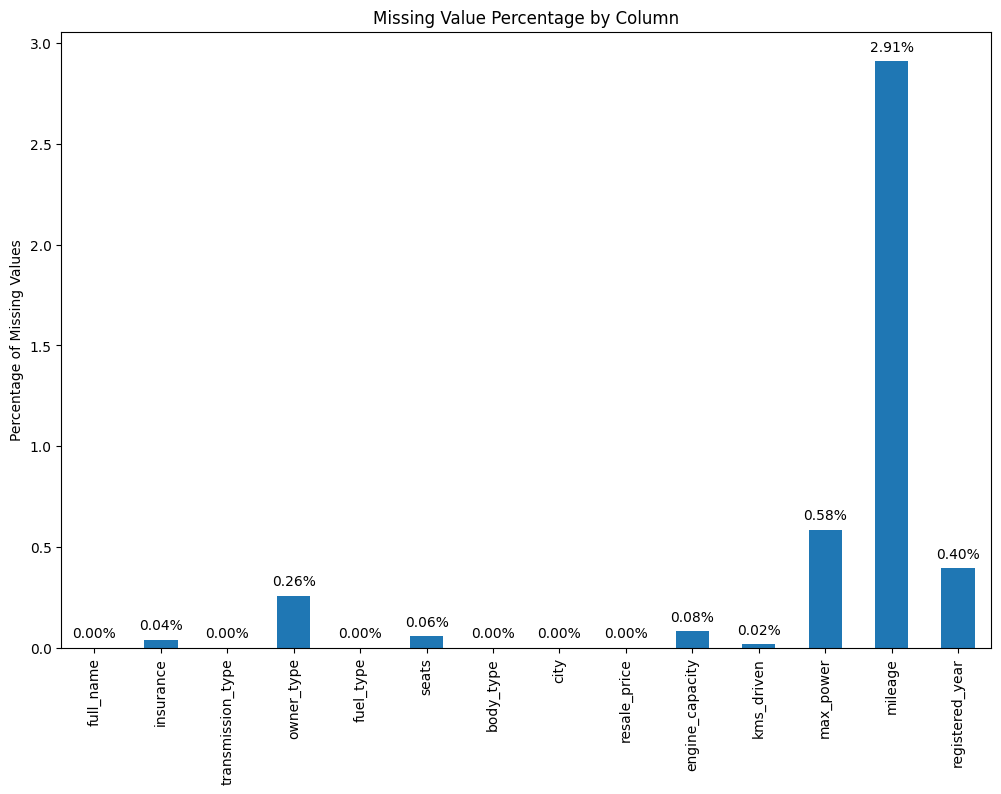

In [124]:
# vẽ bar chart phần trăm missing value và hiện số phần trăm
missing_percent = eda_df.isna().mean() * 100
missing_percent.plot(kind='bar')

for i, v in enumerate(missing_percent):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha='center')

plt.ylabel('Percentage of Missing Values')
plt.title('Missing Value Percentage by Column')
plt.show()

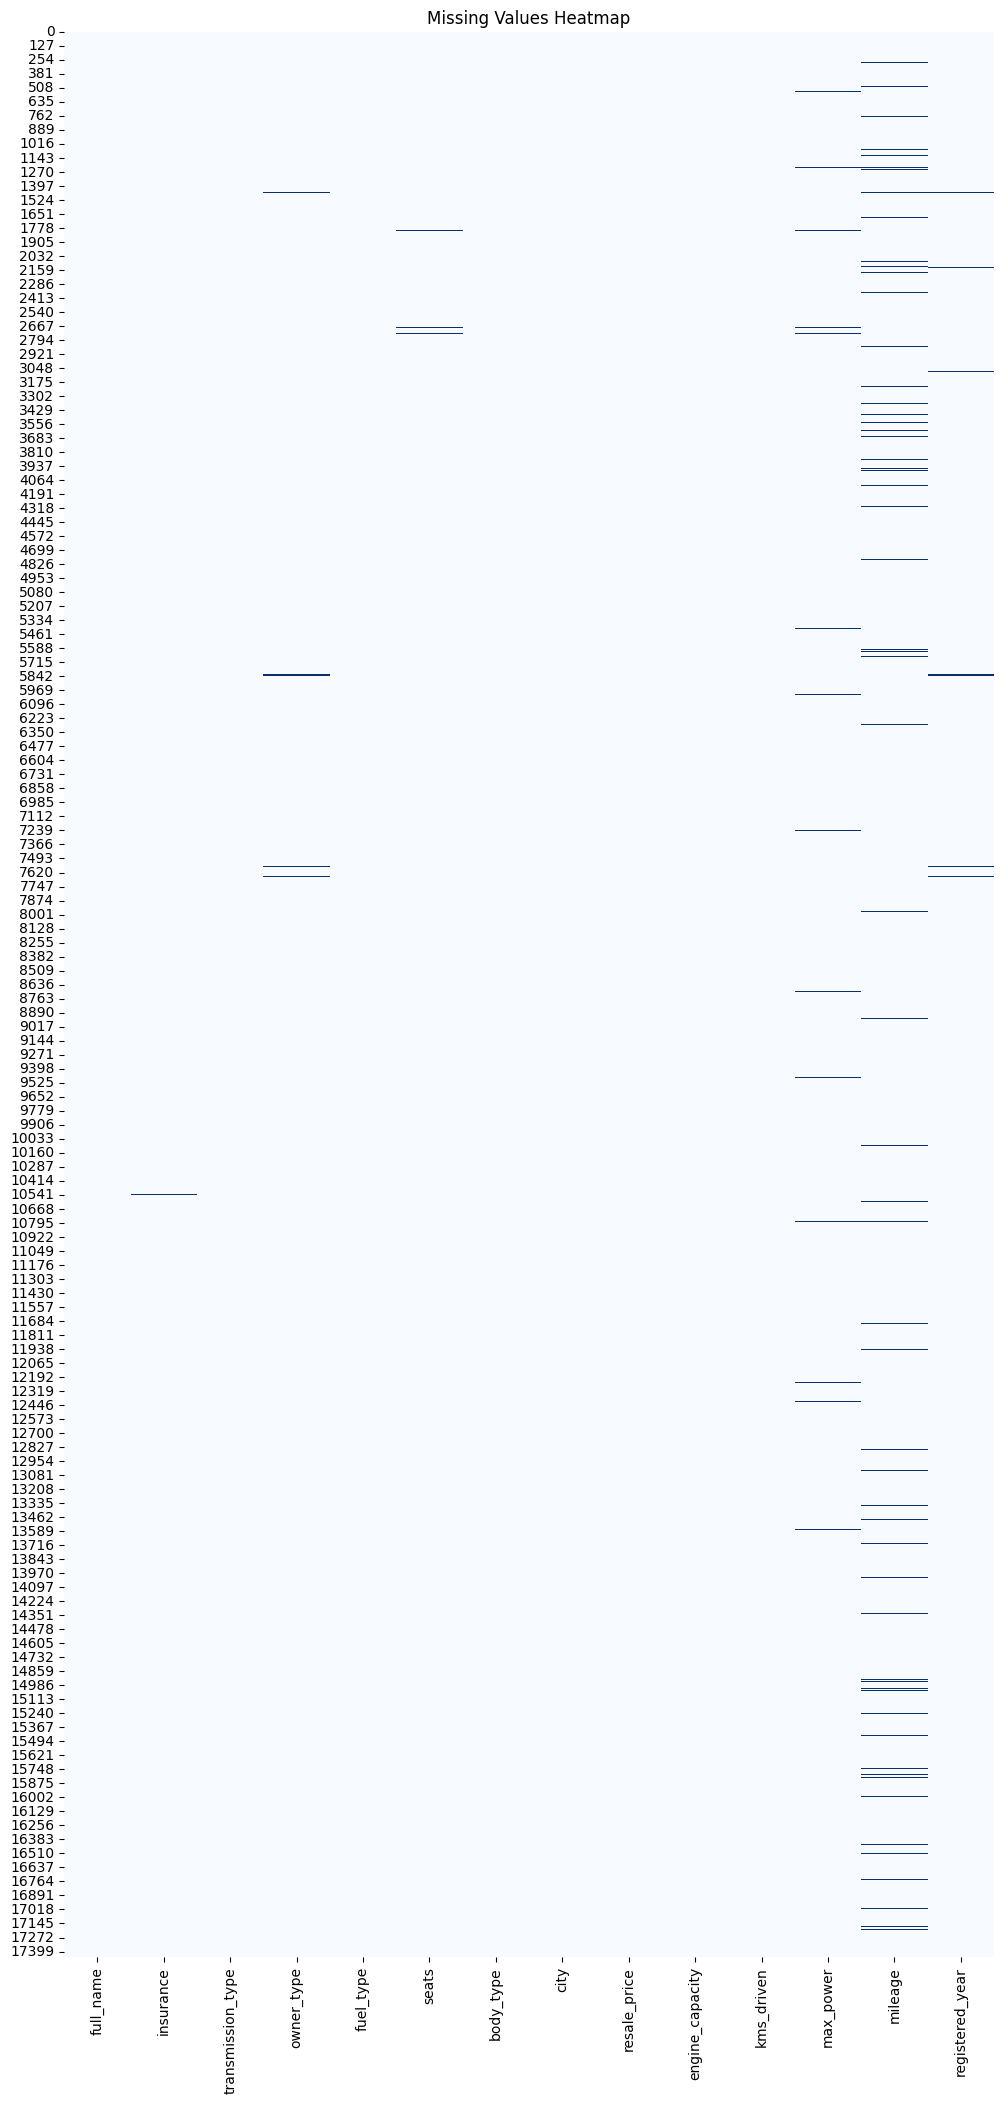

In [125]:
# Vẽ missing heatmap
plt.figure(figsize=(12, 25))
sns.heatmap(eda_df.isna(), cbar=False, cmap='Blues')
plt.title('Missing Values Heatmap')
plt.show()

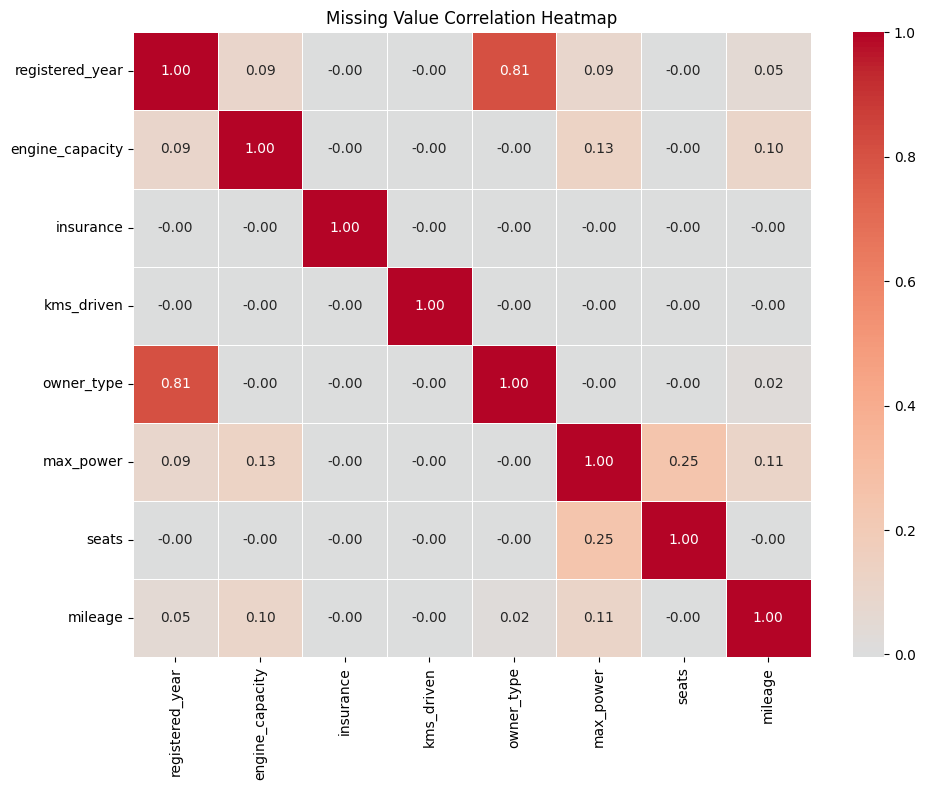

In [126]:
# heapmap tương quan các giá trị thiếu
missing_matrix = df.isna().astype(int)
missing_cols = missing_matrix.columns[missing_matrix.sum() > 0]
missing_matrix = missing_matrix[missing_cols]
missing_corr = missing_matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    missing_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Missing Value Correlation Heatmap")
plt.tight_layout()
plt.show()

Nhận xét: 
* **MCAR (Missing Completely At Random)**: Insurance, Kms Driven
    * Quan sát: Sự thiếu hụt dữ liệu bảo hiểm và loại chủ sở hữu rất thấp (< 0.5%) và không có mối tương quan rõ ràng với giá xe hay năm sản xuất.
    * Lý do: Đây có khả năng là lỗi nhập liệu ngẫu nhiên.
    * Xử lý: Sử dụng Mode Imputation (điền giá trị xuất hiện nhiều nhất, ví dụ: "Third Party insurance" hoặc "First Owner").
* **MAR (Missing At Random)**: Max Power, Seats, Registered year, Owner Type, Mileage
    * Quan sát: 
        1. Từ missing correlation heatmap cho thấy registered_year ↔ owner_type = 0.81 (rất cao), có khả năng registered_year phụ thuộc vào owner_type hoặc ngược lại, bên cạnh đó missing value heatmap cho thấy khi registered_year có missing thì đối chiếu qua đều thấy owner_type cũng missing, nhưng có vài dòng thì chỉ có mỗi registered_year là có missing values.
        2. max_power và seats có mối tương quan missing value nhẹ (0.25), nhưng số lượng missing values của seats khá ít (chỉ 10 giá trị null) trong khi đó số lượng missing values của max_power lên tới 102, nên chưa thể kết luận là MAR, cần kiểm định thống kê, nhưng vì cỡ mẫu của seats khá nhỏ nên quyết định dùng thẳng imputation methods vì không ảnh hưởng nhiều.
        3. mileage có tương quan nhẹ với max_power (0.11) và engine_capacity (0.1), trong đó lượng missing values của max_power và mileage khá lớn, có thể đủ cho kiểm định thống kê, còn về engine_capacity thì số lượng missing value khá ít (14 missng values).
    * Lý do: 
        1. Về mặt nghiệp vụ doanh nghiệp có thể xảy ra trường hợp: 
            * Xe đời quá cũ → hồ sơ không đầy đủ → thiếu registered_year
            * Xe nhiều đời chủ (3rd owner trở lên) → giấy tờ không rõ → thiếu registered_year
            * Xe owner_type cao → thiếu registered_year
        2. Có thể là max_power và seats phụ thuộc vào owner_type nếu càng qua tay của nhiều khách hàng thì những thông số này có thể không thêm vào, và dựa vào số lượng missing values có thể thấy là tương quan giữa chúng không nói lên được nhiều. 
        3. Theo nghiệp vụ thì mileage càng cao thì max_power và engine_capacity có thể bị thay đổi nên dẫn tới missing hoặc thông số kỹ thuật thiếu do owner_type.
    * Xử lý:
        1. Dùng Multiple Imputation hoặc Model-based imputation cho registered_year và owner_type
        2. Dùng kiểm định giả thuyết cho 2 biến với owner_type, sau đó nếu kết quả khả quan đúng với giả định thì với seats dùng Mode imputation và KNN imputation, còn max_power thì dùng Median imputation hoặc Regression. Các hypothesis:
            * max_power và seats phụ thuộc vào owner_type
            * max_power phụ thuộc vào seats
        3. Kiểm định giả thuyết sau đó imputation mileage với model-based imputation (Tree-based model):
            * max_power, engine_capacity phụ thuộc vào mileage
            * max_power, engine_capacity phụ thuộc vào owner_type

Có thể đặt hypothesis cho vấn đề này và kiểm định thống kê.

Bảng tổng hợp:
| Biến            | Loại missing | Lý do                         |
| --------------- | ------------ | ----------------------------- |
| registered_year | MAR          | phụ thuộc owner_type (r=0.81) |
| owner_type      | MAR          | phụ thuộc registered_year     |
| max_power       | MAR          | phụ thuộc seats               |
| seats           | MAR          | phụ thuộc max_power           |
| engine_capacity | MAR nhẹ      | phụ thuộc logic xe            |
| mileage         | MAR nhẹ      | liên quan engine_capacity     |
| insurance       | MCAR         | không tương quan              |
| kms_driven      | MCAR         | không tương quan              |

#### 4.2.2. Statistical testing
1. Missing value của max_power và seats phụ thuộc owner_type
2. Missing value max_power phụ thuộc vào seats
3. Missing value max_power, engine_capacity phụ thuộc vào mileage
4. Missing value engine_capacity phụ thuộc vào owner_type

##### 1. max_power và seats phụ thuộc owner_type

Kiểm định Chi-squared

In [127]:
from scipy.stats import chi2_contingency

def test_missing_dependency(df, alpha = 0.05, missing_col=None, group_col=None):
    missing_indicator = df[missing_col].isna()
    contingency_table = pd.crosstab(df[group_col], missing_indicator)
    contingency_table.columns = ['Not Missing', 'Missing']
    chi2, p, dof, expected = chi2_contingency(contingency_table)
 
    print("Bảng tần số (Contingency Table):")
    print(contingency_table)
    print(f"Chi2 Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4e}") 
    
    if p < alpha:
        print(f"Kết luận: P-value < {alpha} => BÁC BỎ H0.")
        print(f"Việc thiếu dữ liệu của '{missing_col}' PHỤ THUỘC vào '{group_col}'.")
        print("=> Cơ chế có thể là MAR (Missing At Random).")
    else:
        print(f"Kết luận: P-value >= {alpha} => KHÔNG ĐỦ BẰNG CHỨNG bác bỏ H0.")
        print(f"Việc thiếu dữ liệu của '{missing_col}' KHÔNG phụ thuộc vào '{group_col}'.")
        print("=> Cơ chế có thể là MCAR (Missing Completely At Random).")

In [128]:
stats_df = eda_df.copy()
test_missing_dependency(stats_df, alpha=0.05, missing_col='max_power', group_col='owner_type')

Bảng tần số (Contingency Table):
              Not Missing  Missing
owner_type                        
Fifth Owner            48        3
First Owner         12251       42
Fourth Owner          125        2
Second Owner         4118       32
Third Owner           757       23
Chi2 Statistic: 116.4364
P-value: 3.0804e-24
Kết luận: P-value < 0.05 => BÁC BỎ H0.
Việc thiếu dữ liệu của 'max_power' PHỤ THUỘC vào 'owner_type'.
=> Cơ chế có thể là MAR (Missing At Random).


In [129]:
test_missing_dependency(stats_df, alpha=0.05, missing_col='seats', group_col='owner_type')

Bảng tần số (Contingency Table):
              Not Missing  Missing
owner_type                        
Fifth Owner            51        0
First Owner         12290        3
Fourth Owner          127        0
Second Owner         4144        6
Third Owner           779        1
Chi2 Statistic: 8.6047
P-value: 7.1778e-02
Kết luận: P-value >= 0.05 => KHÔNG ĐỦ BẰNG CHỨNG bác bỏ H0.
Việc thiếu dữ liệu của 'seats' KHÔNG phụ thuộc vào 'owner_type'.
=> Cơ chế có thể là MCAR (Missing Completely At Random).


##### 2. max_power phụ thuộc vào seats

In [130]:
test_missing_dependency(stats_df, alpha=0.05, missing_col='max_power', group_col='seats')

Bảng tần số (Contingency Table):
       Not Missing  Missing
seats                      
2.0              9        2
4.0            205        0
5.0          15244       82
6.0            191        3
7.0           1509        2
8.0            156        4
9.0             23        1
10.0             4        0
14.0             1        0
Chi2 Statistic: 90.6935
P-value: 3.3626e-16
Kết luận: P-value < 0.05 => BÁC BỎ H0.
Việc thiếu dữ liệu của 'max_power' PHỤ THUỘC vào 'seats'.
=> Cơ chế có thể là MAR (Missing At Random).


##### 3. Missing max_power, engine_capacity phụ thuộc vào mileage

In [131]:
from scipy.stats import mannwhitneyu

def test_missing_dependency_numerical(df, missing_col, num_col):
    group_missing = df[df[missing_col].isna()][num_col].dropna()
    group_not_missing = df[~df[missing_col].isna()][num_col].dropna()
    stat, p = mannwhitneyu(group_missing, group_not_missing)
    
    print(f"Mean '{num_col}' khi missing: {group_missing.mean():.2f}")
    print(f"Mean '{num_col}' khi không missing: {group_not_missing.mean():.2f}")
    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"\nKết luận: P-value < {alpha} => BÁC BỎ H0.")
        print(f"Có sự khác biệt về phân phối '{num_col}' giữa nhóm missing và không missing.")
        print(f"=> Việc thiếu dữ liệu '{missing_col}' CÓ PHỤ THUỘC vào '{num_col}' (MAR).")
    else:
        print(f"\nKết luận: P-value >= {alpha} => KHÔNG ĐỦ BẰNG CHỨNG bác bỏ H0.")
        print(f"Không có sự khác biệt về '{num_col}' giữa các nhóm.")
        print(f"=> Việc thiếu dữ liệu có thể là ngẫu nhiên (MCAR) đối với biến này.")

In [132]:
test_missing_dependency_numerical(stats_df, 'max_power', 'mileage')

Mean 'mileage' khi missing: 17.54
Mean 'mileage' khi không missing: 19.83
Mann-Whitney U statistic: 429782.0
P-value: 3.7097e-06

Kết luận: P-value < 0.05 => BÁC BỎ H0.
Có sự khác biệt về phân phối 'mileage' giữa nhóm missing và không missing.
=> Việc thiếu dữ liệu 'max_power' CÓ PHỤ THUỘC vào 'mileage' (MAR).


##### 4. Missing engine_capacity phụ thuộc vào owner_type

In [133]:
test_missing_dependency(stats_df, alpha=0.05, missing_col='engine_capacity', group_col='owner_type')

Bảng tần số (Contingency Table):
              Not Missing  Missing
owner_type                        
Fifth Owner            51        0
First Owner         12283       10
Fourth Owner          127        0
Second Owner         4149        1
Third Owner           777        3
Chi2 Statistic: 10.7605
P-value: 2.9392e-02
Kết luận: P-value < 0.05 => BÁC BỎ H0.
Việc thiếu dữ liệu của 'engine_capacity' PHỤ THUỘC vào 'owner_type'.
=> Cơ chế có thể là MAR (Missing At Random).


In [134]:
test_missing_dependency(stats_df, alpha=0.05, missing_col='mileage', group_col='owner_type')

Bảng tần số (Contingency Table):
              Not Missing  Missing
owner_type                        
Fifth Owner            50        1
First Owner         11861      432
Fourth Owner          127        0
Second Owner         4095       55
Third Owner           765       15
Chi2 Statistic: 59.7915
P-value: 3.2087e-12
Kết luận: P-value < 0.05 => BÁC BỎ H0.
Việc thiếu dữ liệu của 'mileage' PHỤ THUỘC vào 'owner_type'.
=> Cơ chế có thể là MAR (Missing At Random).


**Kết luận**

* MCAR: seats, kms_driven, insurance
    * seats: mode imputation
    * kms_driven: median imputation
    * insurance: mode imputation
* MAR: max_power, engine_capacity, mileage, owner_type, registered_year
    * max_power: KNN Imputation
    * engine_capacity: KNN Imputation
    * mileage: KNN Imputation
    * owner_type: mode imputation | imputation model-based
    * registered_year: KNN Imputation

### 4.3 Imputation Techniques

In [135]:
num_cols_missing = ['engine_capacity', 'kms_driven', 'max_power', 'mileage', 'registered_year']
cat_cols_missing = ['insurance', 'owner_type', 'seats']

In [136]:
missing_df = eda_df.copy()

#### 4.3.1. Xử lý Categorical (Impute bằng Mode)

In [137]:
cat_imputation_cols = ['insurance', 'owner_type', 'seats']
cat_imputer = SimpleImputer(strategy='most_frequent')
missing_df[cat_imputation_cols] = cat_imputer.fit_transform(missing_df[cat_imputation_cols])

#### 4.3.2. Xử lý Numerical MCAR (Impute bằng Median)

In [138]:
median_imputer = SimpleImputer(strategy='median')
missing_df[['kms_driven']] = median_imputer.fit_transform(missing_df[['kms_driven']])

#### 4.3.3. Xử lý Numerical MAR (Impute bằng KNN)

In [139]:
knn_imputer = KNNImputer(n_neighbors=5)
target_cols = ['max_power', 'engine_capacity', 'mileage', 'registered_year']

missing_df[target_cols] = knn_imputer.fit_transform(missing_df[target_cols])

### 4.4 Compare Imputation Methods

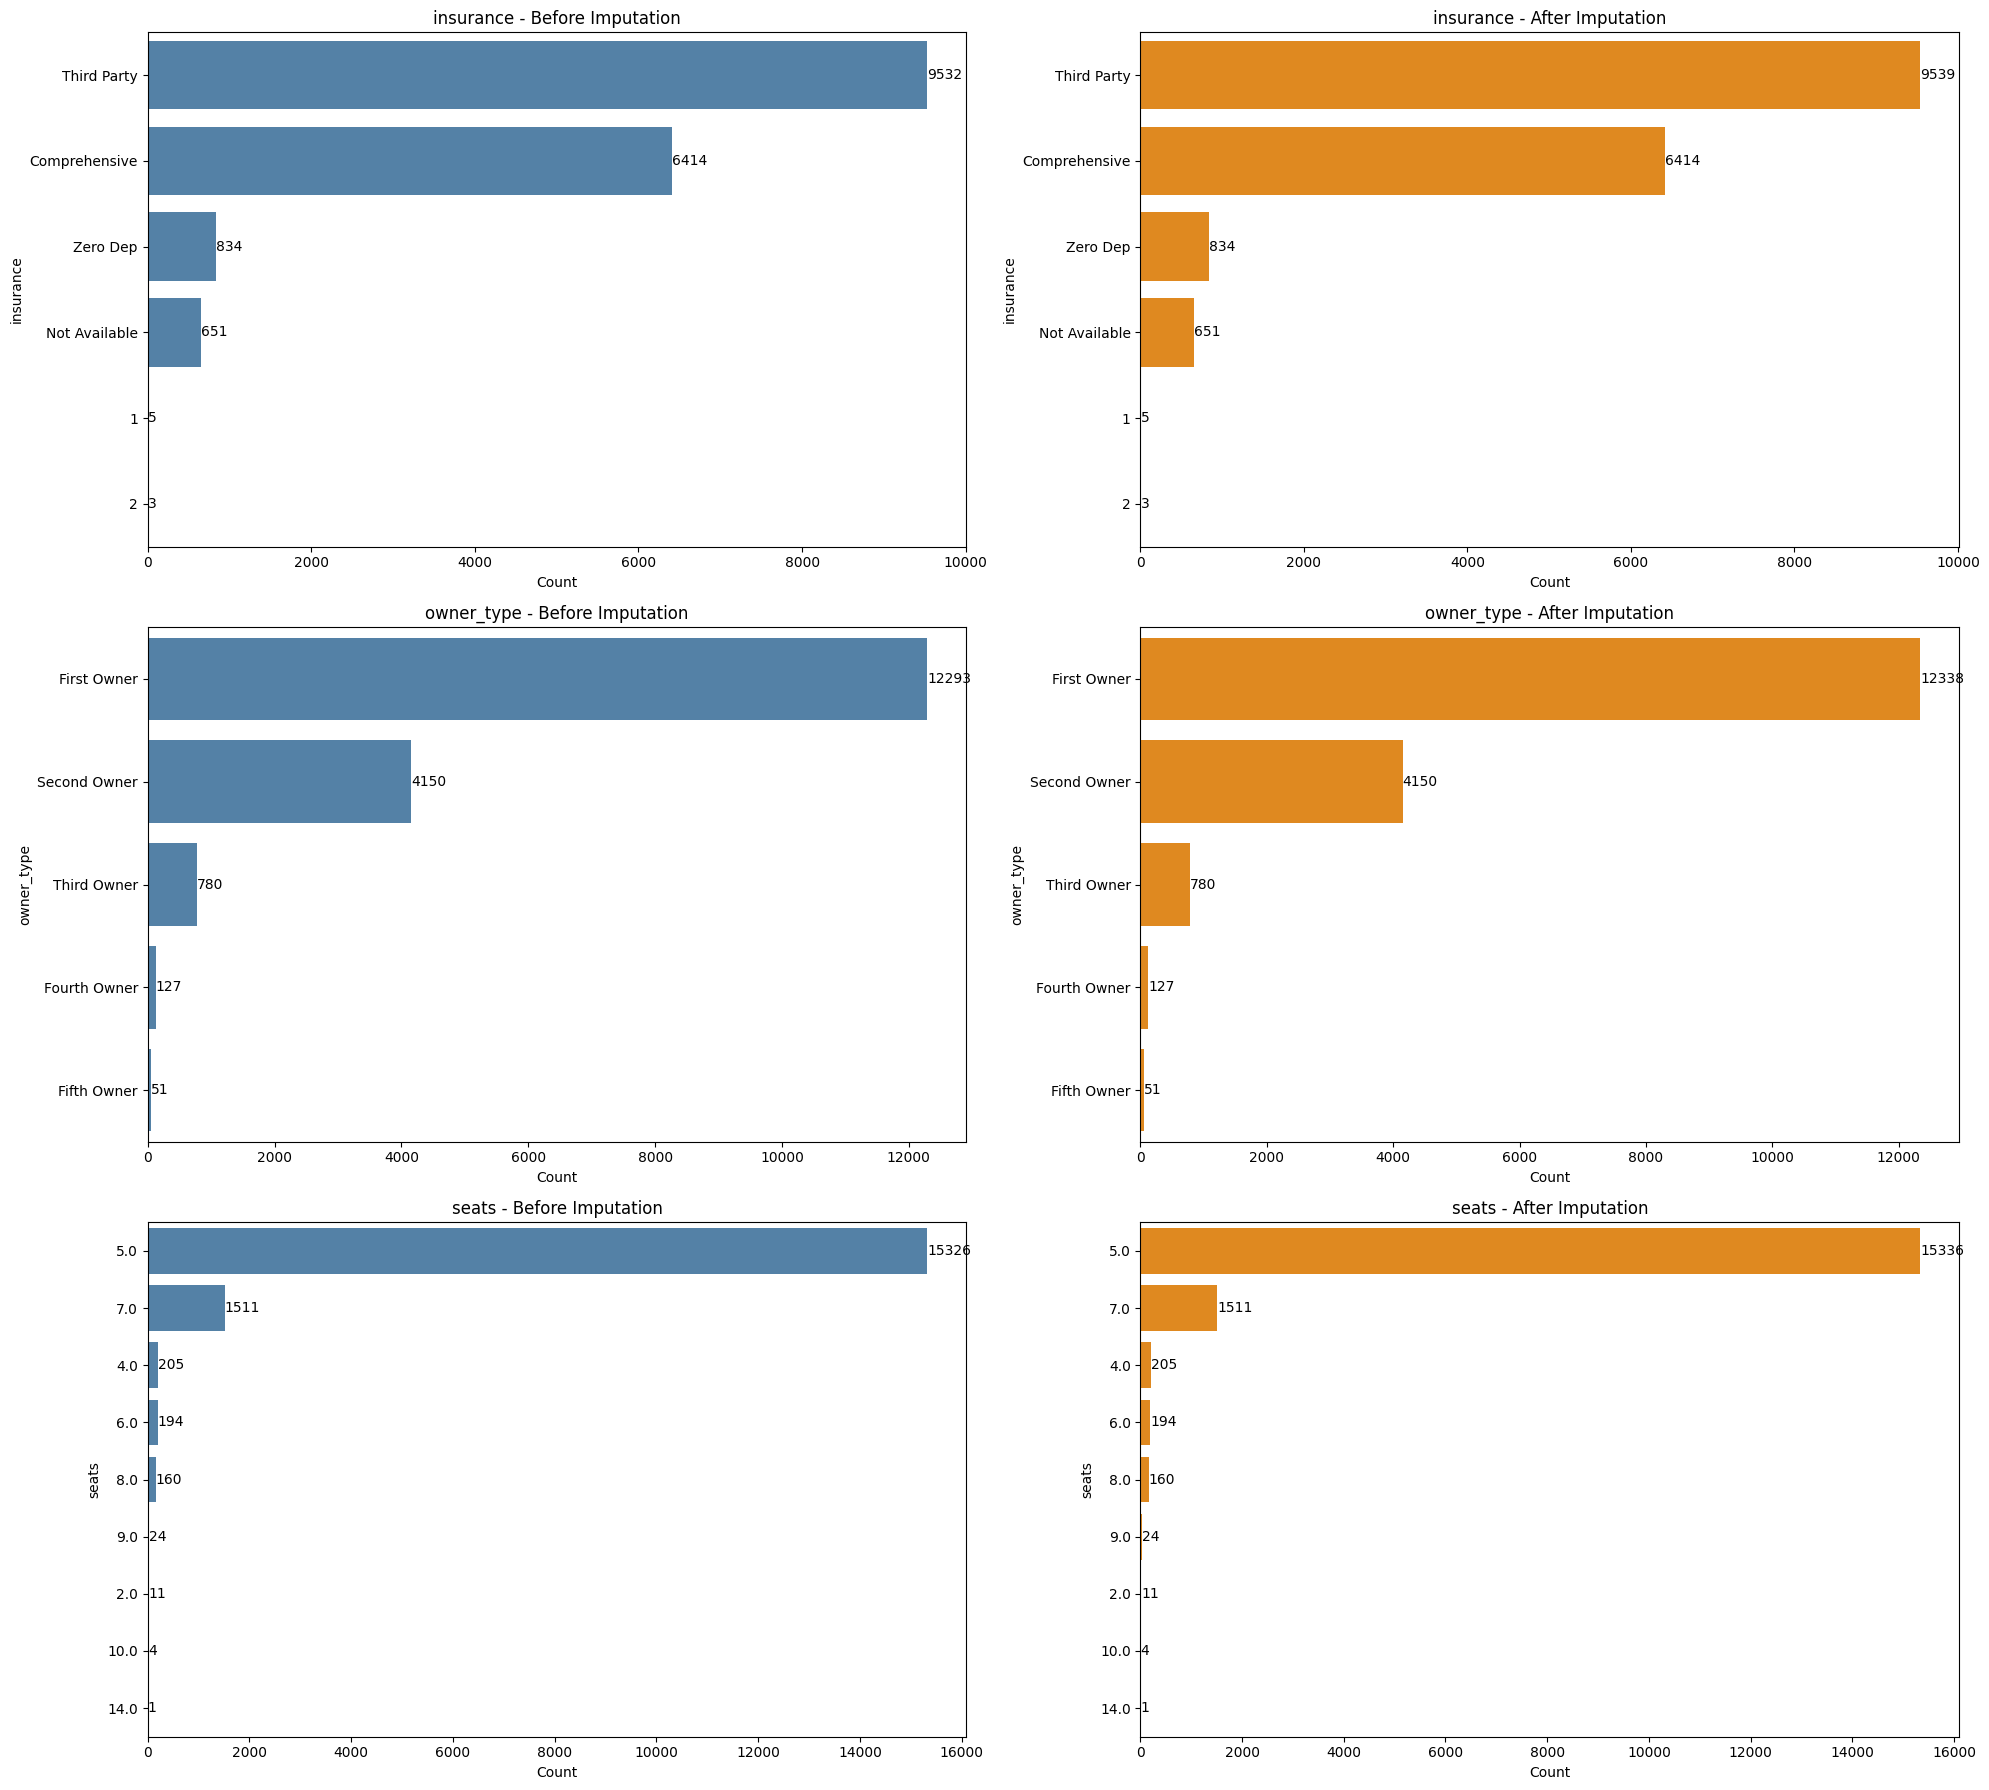

In [140]:
# Vẽ biểu đồ phân phối của các cột categorical có giá trị missing và sau khi impute để so sánh
def plot_categorical_comparison(df_before, df_after, cols):
    n_cols = len(cols)
    # Tạo figure lớn với số dòng tương ứng số cột cần vẽ
    fig, axes = plt.subplots(n_cols, 2, figsize=(20, 6 * n_cols))
    
    # Xử lý trường hợp chỉ có 1 cột (axes không phải mảng 2 chiều)
    if n_cols == 1:
        axes = [axes]

    for i, column in enumerate(cols):
        # Plot Before (Left) - Màu steelblue
        sns.countplot(y=df_before[column], order=df_before[column].value_counts().index, ax=axes[i][0], color='steelblue')
        axes[i][0].set_title(f'{column} - Before Imputation')
        axes[i][0].set_xlabel('Count')
        axes[i][0].set_ylabel(column)

        for p in axes[i][0].patches:
            width = p.get_width()
            axes[i][0].text(
                width + 0.5,
                p.get_y() + p.get_height()/2,
                int(width), 
                va='center'
            )
        
        # Plot After (Right) - Màu darkorange
        sns.countplot(y=df_after[column], order=df_after[column].value_counts().index, ax=axes[i][1], color='darkorange')
        axes[i][1].set_title(f'{column} - After Imputation')
        axes[i][1].set_xlabel('Count')
        axes[i][1].set_ylabel(column)

        for p in axes[i][1].patches:
            width = p.get_width()
            axes[i][1].text(
                width + 0.5,
                p.get_y() + p.get_height()/2,
                int(width),
                va='center'
            )
    
    plt.tight_layout()
    plt.show()

plot_categorical_comparison(eda_df, missing_df, cat_imputation_cols)

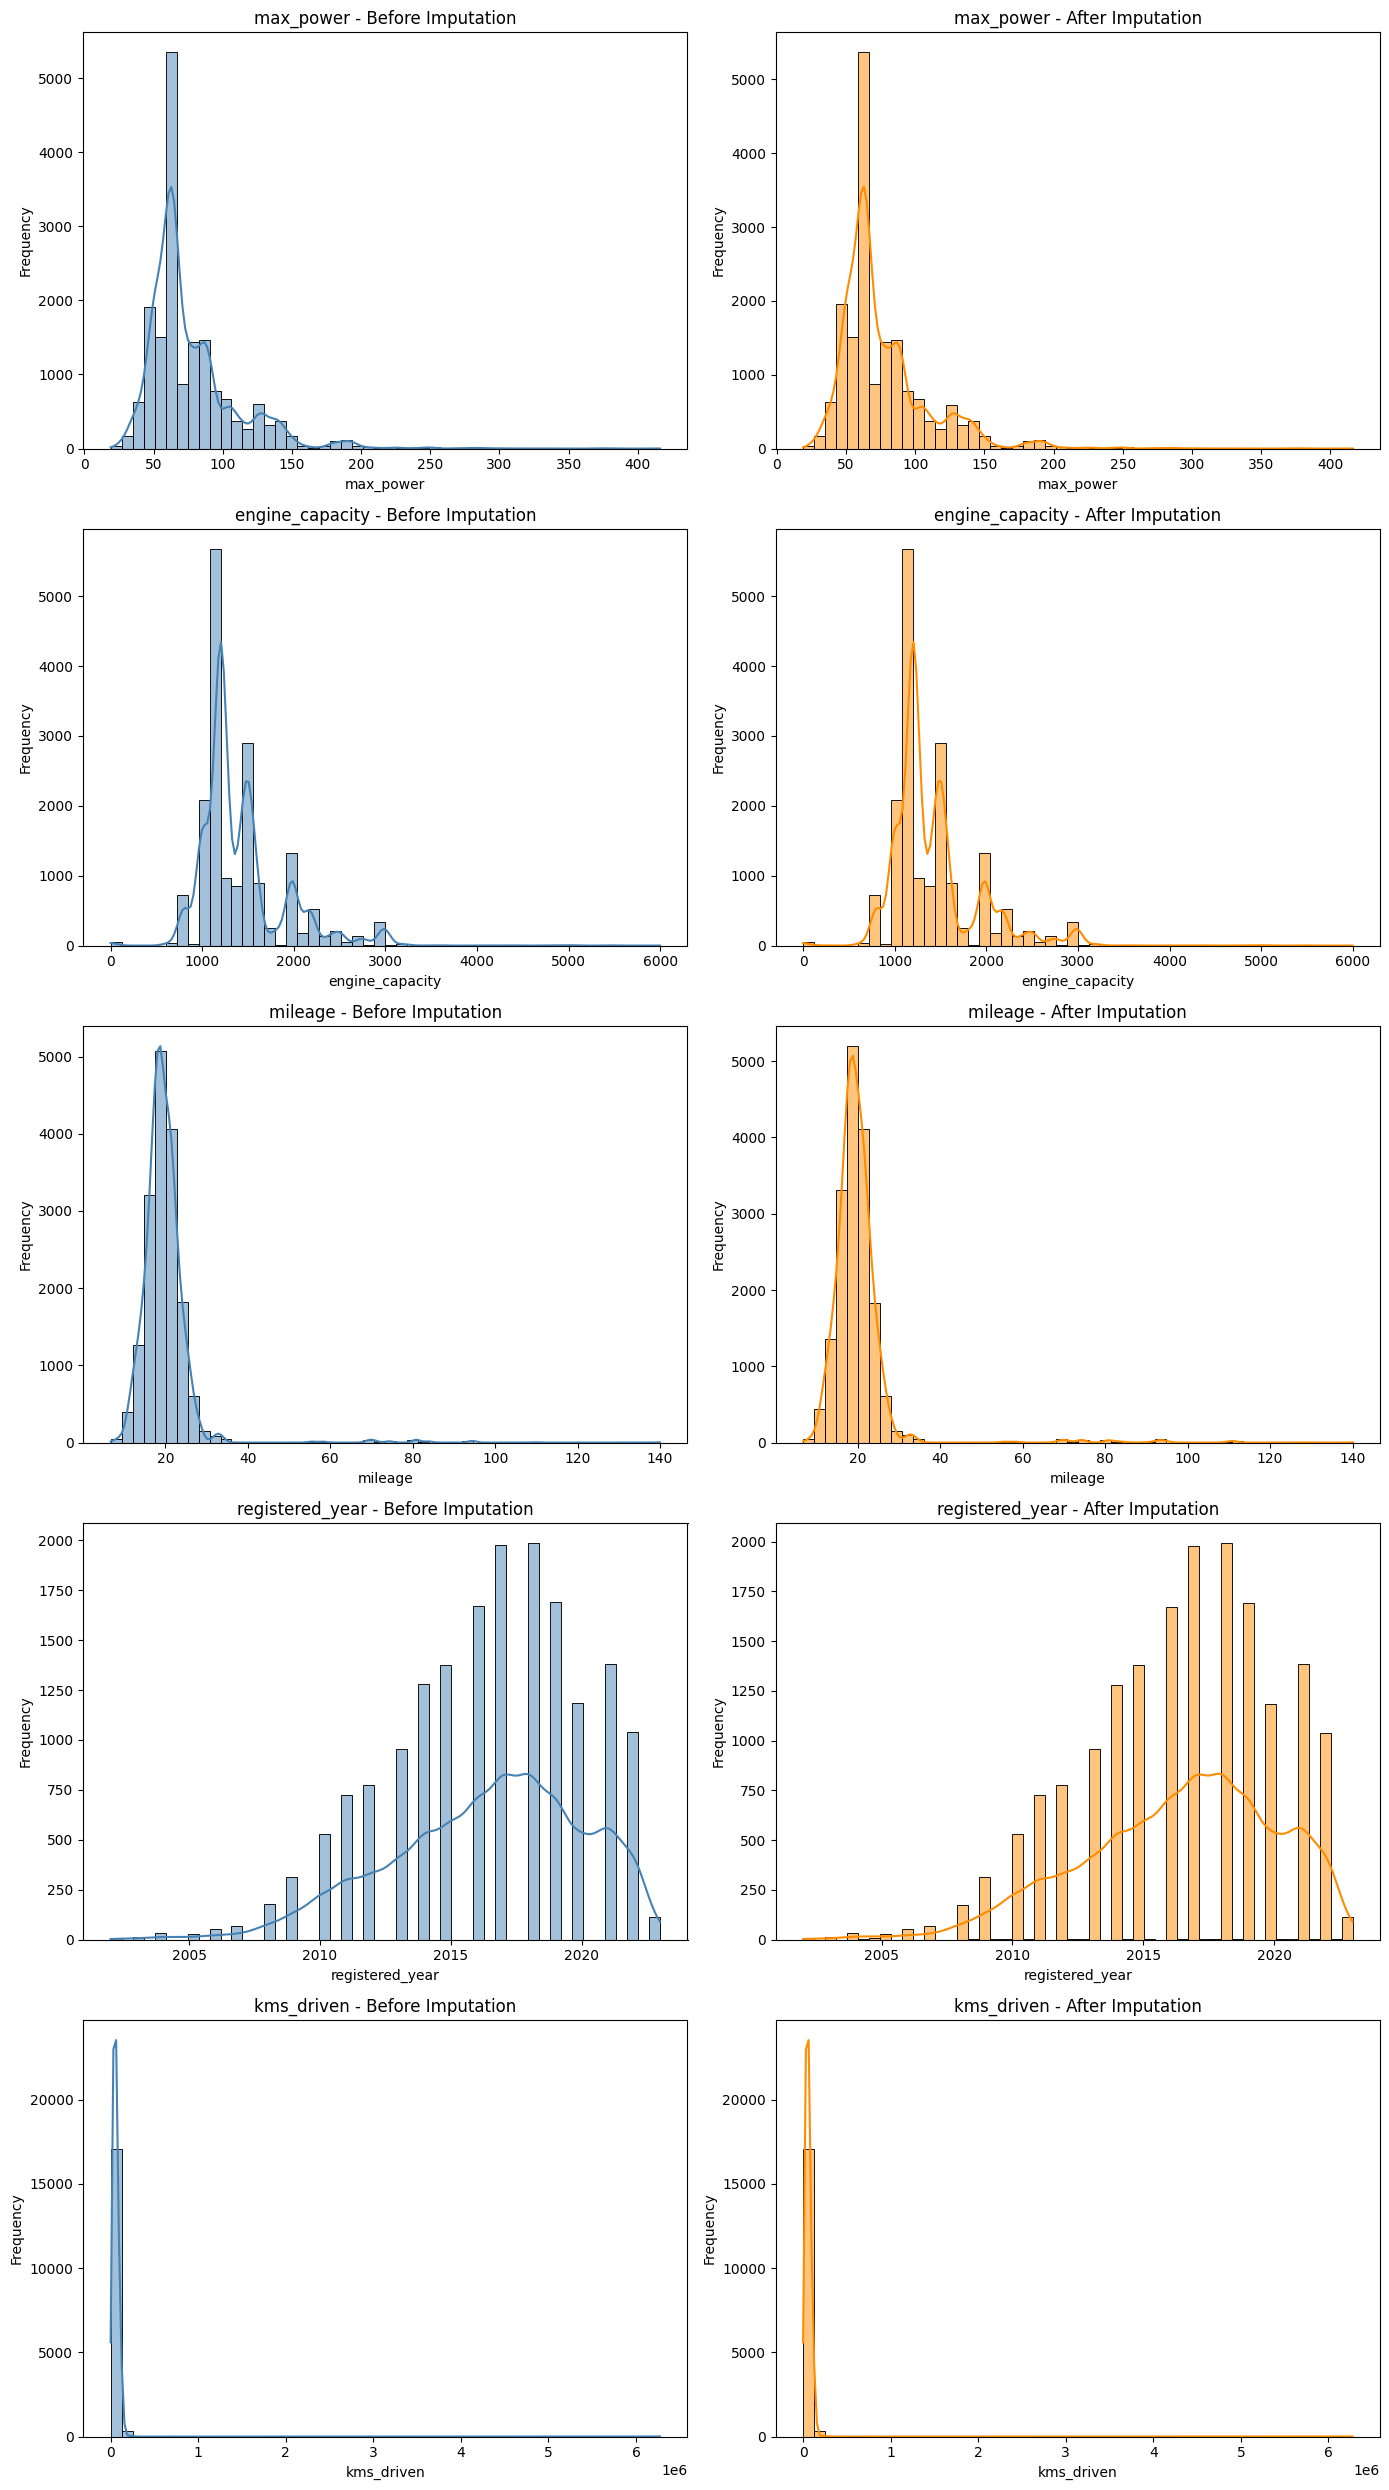

In [141]:
# Vẽ biểu đồ phân phối của các cột numerical có giá trị missing và sau khi impute để so sánh ở chung 1 ảnh 
def plot_numerical_comparison(df_before, df_after, cols):
    n_cols = len(cols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 5 * n_cols))
    
    if n_cols == 1:
        axes = [axes]

    for i, column in enumerate(cols):
        sns.histplot(df_before[column].dropna(), kde=True, bins=50, ax=axes[i][0], color='steelblue')
        axes[i][0].set_title(f'{column} - Before Imputation')
        axes[i][0].set_xlabel(column)
        axes[i][0].set_ylabel('Frequency')

        sns.histplot(df_after[column].dropna(), kde=True, bins=50, ax=axes[i][1], color='darkorange')
        axes[i][1].set_title(f'{column} - After Imputation')
        axes[i][1].set_xlabel(column)
        axes[i][1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

cols = target_cols + ['kms_driven'] 
plot_numerical_comparison(eda_df, missing_df, cols)

In [142]:
# Lưu kết quả đã impute vào file CSV mới
output_dir_imputed = os.path.join(parrent_path, 'data', 'tabular', 'cleaned', 'car_resale_prices_imputed.csv')
missing_df.to_csv(output_dir_imputed, index=False)

---

## 5. Data Normalization

### 5.1 Rationale
**Tại sao cần normalization:**
- Normalization là một phương pháp biến đổi range của giá trị feature về một giá trị cụ thể, thường là giữa 0 và 1.
- Nó biến đổi, chia tỷ lệ của đặc trưng thành standard range (khoảng dữ liệu theo phân phối chuẩn).
- Normalization đảm bảo cho tất cả features có đóng góp dạng unit, bằng nhau để cải thiện thuật toán machine learning:
    + Tối ưu hóa gradient decent, tăng tốc hội tụ.
- Đặc tính:
    + Ánh xạ min và max của khoảng dữ liệu thành một khoảng cho trước
    + Bảo toàn mối quan hệ tương đối của dữ liệu gốc


**Các phương pháp:**
1. **Min-Max Scaling:** [Giải thích và khi nào dùng]
    * Min-Max Scaling là phương pháp đưa dữ liệu về một khoảng cố định, thường là: [0, 1]
    * Cách hoạt động:
        1. Dịch dữ liệu về 0
        2. Chuẩn hóa theo độ rộng range (Không thay đổi thứ tự dữ liệu hay thay đổi hình dạng phân phối)
    * Nhạy với outlier khi scaling
    * Dùng khi: 
        * Dữ liệu không có nhiều outlier
        * Thuật toán nhạy với scale: KNN, K-means, NNs, SVM
        * Khi cần dữ liệu nằm trong khoảng cố định (ví dụ ảnh pixel 0–1)
    * Không nên dùng khi: 
        * Dữ liệu có nhiều outlier lớn -> sẽ làm khoảng scale bị lệch quá nhiều qua outlier, tập trung quá nhiều vào khoảng nhỏ
        * Phân phối có đuôi dài (long tail)
        * Khi cần tính ổn định cao trước dữ liệu mới

2. **Standardization (Z-score):**
    * Standardization (Z-score Scaling) là kỹ thuật chuẩn hóa dữ liệu bằng cách biến đổi đặc trưng sao cho:
        * Trung bình (mean) = 0
        * Độ lệch chuẩn (standard deviation) = 1
    * Dùng khi 
        * Thuật toán giả định dữ liệu phân phối gần Gaussian:
            * Linear Regression
            * Logistic Regression
            * PCA
        * Thuật toán dựa trên gradient:
            * Neural Networks
            * SVM
        * Dữ liệu có outlier vừa phải
        * Feature có scale rất khác nhau
    * Không cần dùng khi: áp dụng vào giải thuật không ảnh hưởng bởi scale (tree-based model)
        * Decision Tree
        * Random forest
        * XGBoost

    * Điểm mạnh: 
        * Ít bị ảnh hưởng bởi outlier hơn Min-Max
        * Phù hợp với nhiều mô hình tuyến tính
        * Giúp tối ưu gradient descent nhanh và ổn định hơn
        * Không bị giới hạn trong khoảng cố định
    * Điểm yếu: 
        * Không giới hạn giá trị (có thể rất lớn hoặc rất nhỏ)
        * Không phù hợp nếu cần dữ liệu trong khoảng cụ thể (ví dụ 0–1)
        * Nếu dữ liệu cực lệch (skewed mạnh) → vẫn bị ảnh hưởng

3. **Robust Scaling:** [Giải thích và khi nào dùng]
    * Robust Scaling là kỹ thuật chuẩn hóa dữ liệu dựa trên:
        * Median (trung vị)
        * IQR (Interquartile Range – khoảng tứ phân vị)
    * Công thức: $$ x_{scaled} = \frac{X - median}{IQR} $$ 
        * Trong đó:
            * median: giá trị trung vị (Q2)
            * IQR = Q3 - Q1
                * Q1: 25th percentile
                * Q3: 75th percentile
    * Dùng khi:
        * Dữ liệu có nhiều outlier
        * Phân phối lệch mạnh (skewed distribution)
        * Feature có đuôi dài (long tail)
    * Không cần khi:
        * Dữ liệu đã sạch, không có outlier
        * Cần scale về khoảng cố định như [0,1]

    * Điểm mạnh
        * Rất ít bị ảnh hưởng bởi outlier
        * Giữ cấu trúc phân phối tốt hơn Standardization khi dữ liệu lệch
        * Ổn định hơn Min-Max

### 5.2 Check for Outliers First

In [143]:
normalized_df = missing_df.copy()
normalized_df.head()

,full_name,insurance,transmission_type,owner_type,fuel_type,seats,body_type,city,resale_price,engine_capacity,kms_driven,max_power,mileage,registered_year
0,2017 Maruti Baleno 1.2 Alpha,Third Party,Manual,First Owner,Petrol,5.0,Hatchback,Agra,545000.0,1197.0,40000.0,61.97,21.40,2017.0
1,2018 Tata Hexa XTA,Third Party,Automatic,First Owner,Diesel,7.0,MUV,Agra,1000000.0,2179.0,70000.0,114.73,17.60,2018.0
2,2015 Maruti Swift Dzire VXI,Third Party,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
3,2015 Maruti Swift Dzire VXI,Third Party,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,62.00,20.85,2015.0
4,2009 Hyundai i10 Magna 1.1,Third Party,Manual,First Owner,Petrol,5.0,Hatchback,Agra,160000.0,1086.0,80000.0,50.74,19.81,2009.0


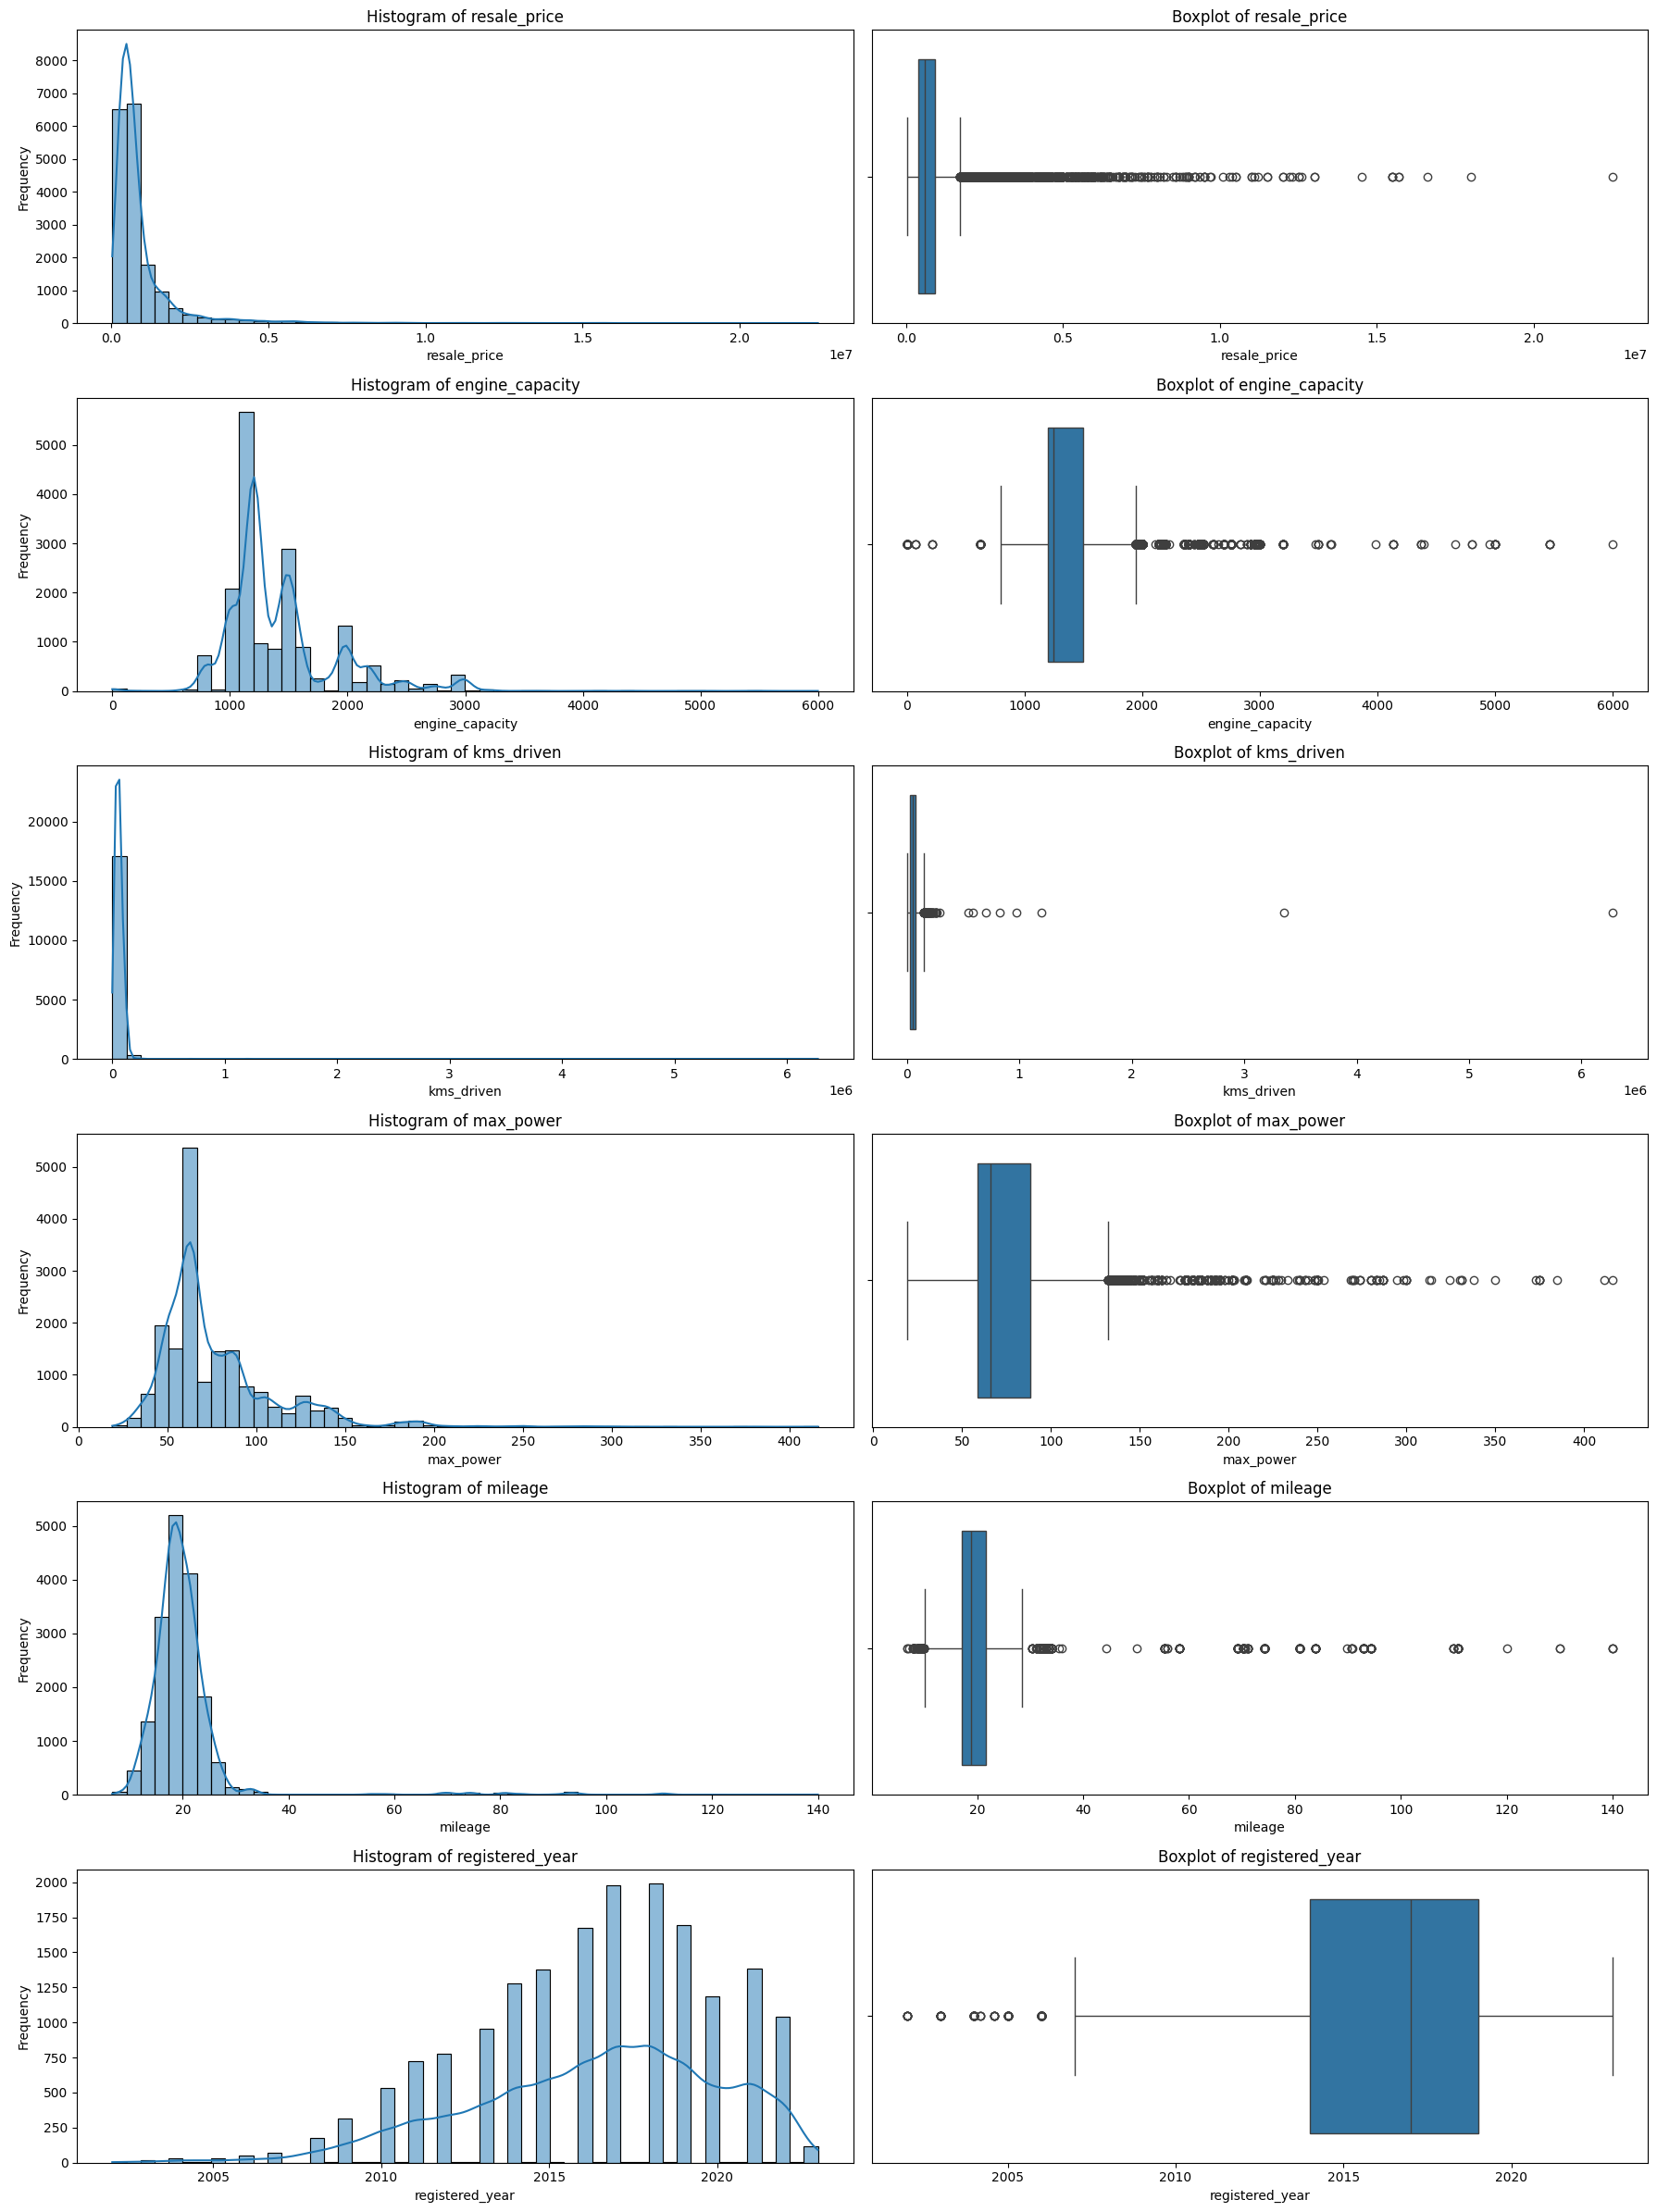

In [144]:
# Vẽ phân phối và boxplot của tất cả cột dữ liệu continuous trong 1 ảnh duy nhất
def plot_all_numerical_distributions(df, num_cols):
    num_plots = len(num_cols)
    plt.figure(figsize=(18, num_plots * 4))

    for i, col in enumerate(num_cols):
        plt.subplot(num_plots, 2, 2*i + 1)
        sns.histplot(df[col].dropna(), kde=True, bins=50)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.subplot(num_plots, 2, 2*i + 2)
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

plot_all_numerical_distributions(normalized_df, num_cols)

Nhận xét:
* Robust scaling: resale_price, engine_capacity, kms_driven, max_power
* Standard scaling (z-score): mileage, registered_year

### 5.3 Apply Normalization Methods

Robust scaling: resale_price, engine_capacity, kms_driven, max_power

In [145]:
# Robust Scaler cho cột cụ thể
def robust_scaler(df, cols):
    scaler = RobustScaler()
    df_scaled = df.copy()
    df_scaled[cols] = scaler.fit_transform(df_scaled[cols])
    return df_scaled

# Standard Scaler
def standard_scaler(df, cols):
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[cols] = scaler.fit_transform(df_scaled[cols])
    return df_scaled


In [146]:
robust_scaled_row = ['resale_price', 'engine_capacity', 'kms_driven', 'max_power']
standard_scaler_row = ['mileage', 'registered_year']

normalized_df_robust_scaled = robust_scaler(normalized_df, robust_scaled_row)
normalized_df_standard_scaled = standard_scaler(normalized_df, standard_scaler_row)

### 5.4 Compare Normalization Methods

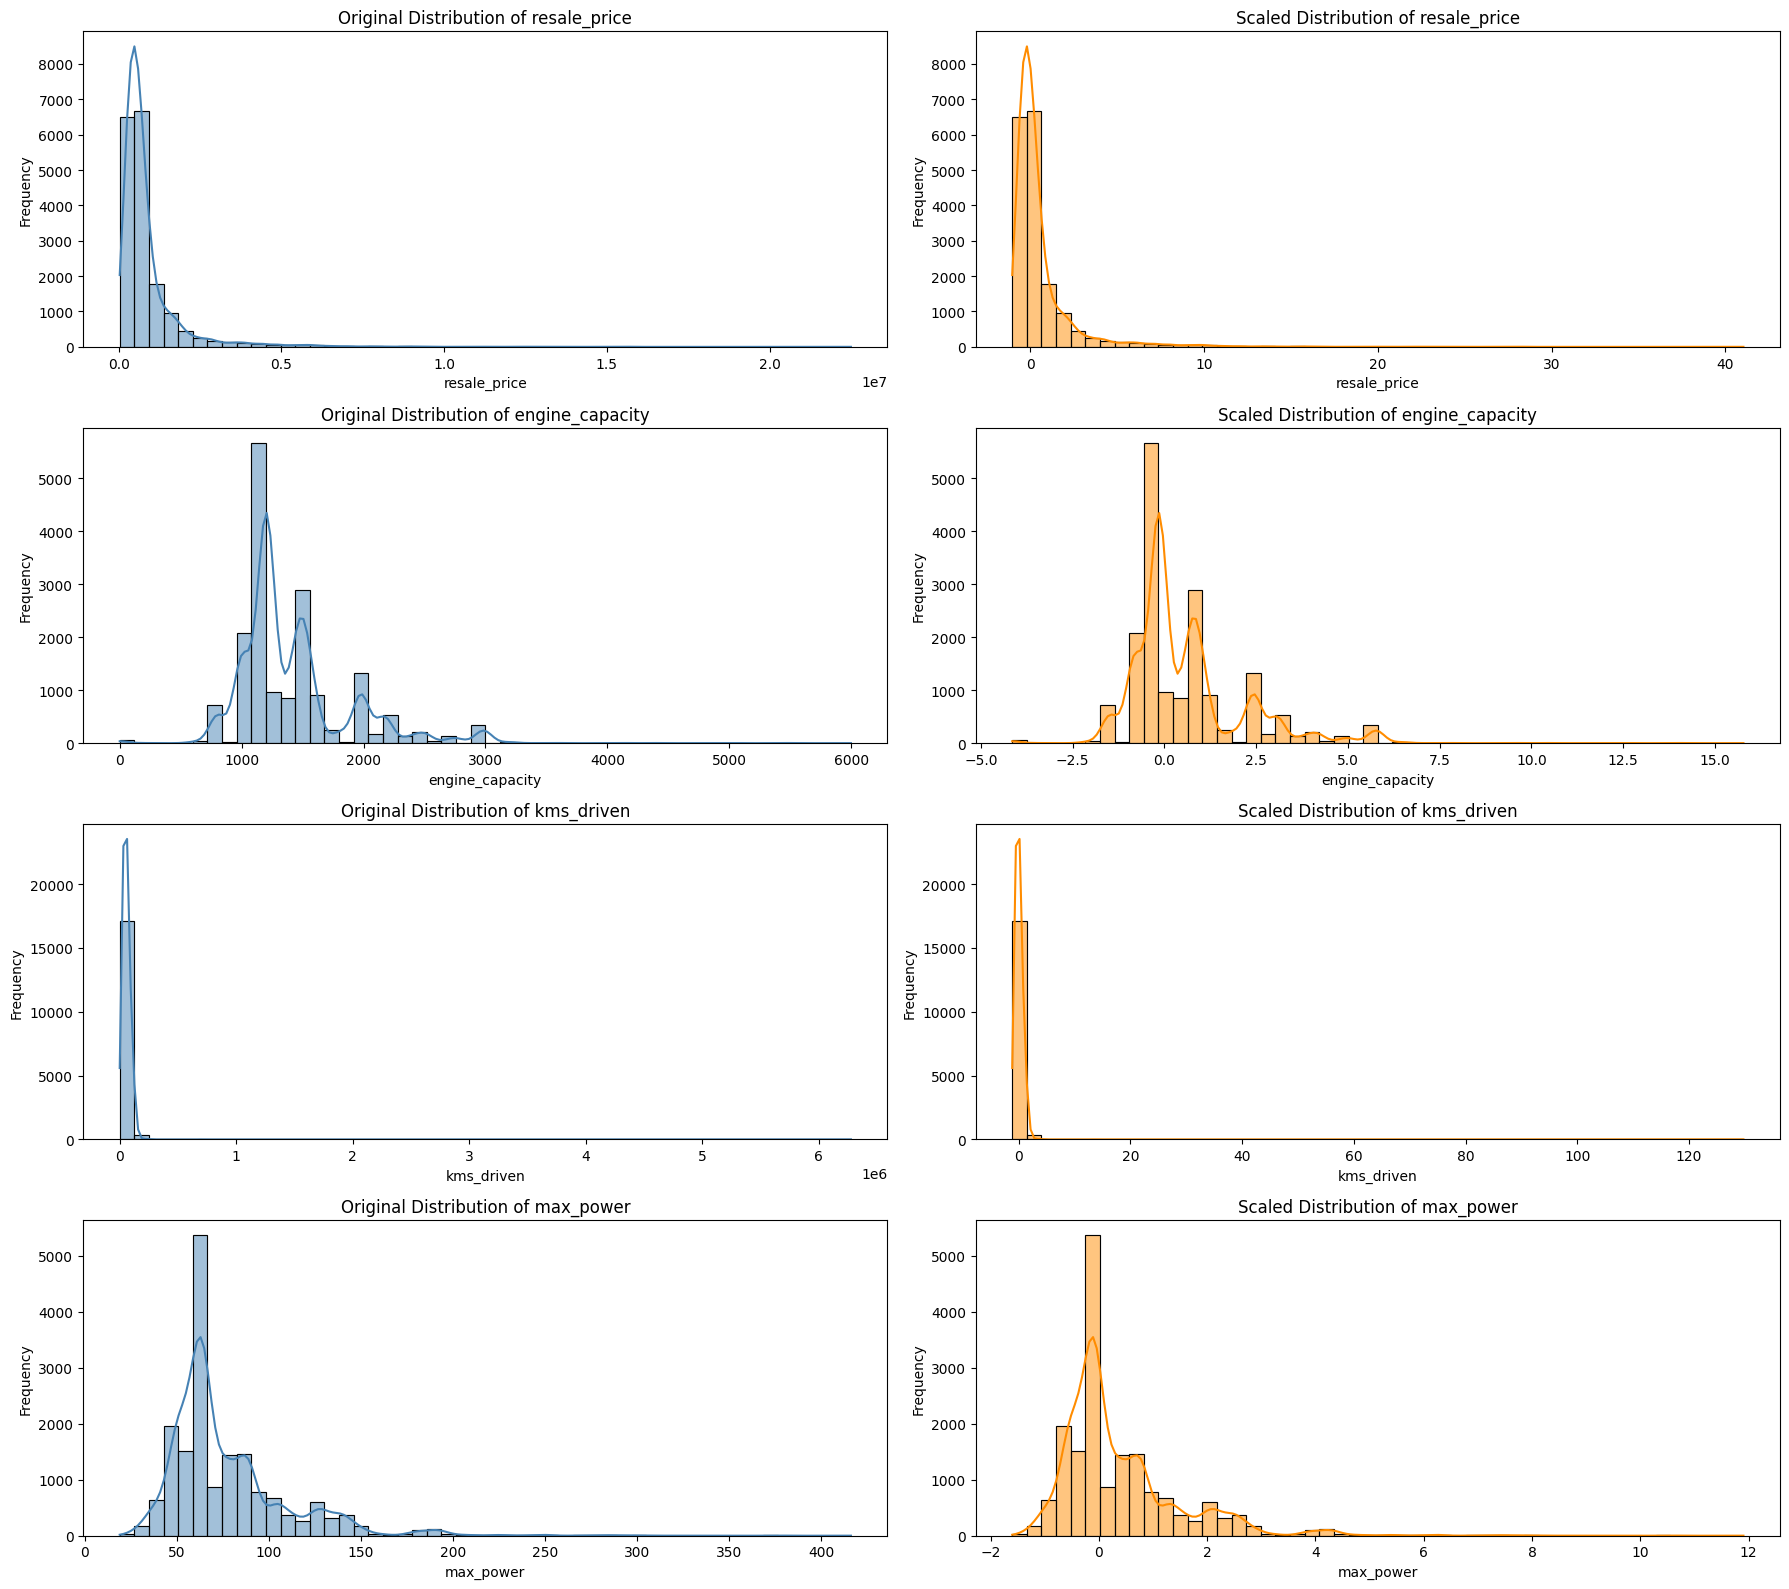

In [147]:
# Vẽ biểu đồ so sánh phân phối trước và sau khi normalize của robust scaled
def compare_distributions_after_scaling(original, scaled_dfs, columns):
    num_cols = len(columns)
    plt.figure(figsize=(18, num_cols * 4))

    for i, col in enumerate(columns):
        plt.subplot(num_cols, 2, 2*i + 1)
        sns.histplot(original[col].dropna(), kde=True, bins=50, color='steelblue')
        plt.title(f'Original Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.subplot(num_cols, 2, 2*i + 2)
        sns.histplot(scaled_dfs[col].dropna(), kde=True, bins=50, color='darkorange')
        plt.title(f'Scaled Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()
compare_distributions_after_scaling(normalized_df, normalized_df_robust_scaled, robust_scaled_row)

Nhận xét:
* Việc chuẩn hóa (scaling) không làm thay đổi hình dáng của dữ liệu. Các đỉnh (peaks), độ lệch (skewness), và khoảng cách tương đối giữa các điểm dữ liệu ở biểu đồ màu xanh hoàn toàn được giữ nguyên ở biểu đồ màu cam.
* Thang đo thay đổi, trục x đã được thu hẹp lại, các giá trị trên trục x của biểu đồ màu cam (có số âm, phần lớn tập trung quanh mốc 0)


In [148]:
# Lưu kết quả đã normalize vào file CSV mới
output_dir_normalized = os.path.join(parrent_path, 'data', 'tabular', 'cleaned', 'car_resale_prices_normalized.csv')
normalized_df = normalized_df_robust_scaled.copy()
normalized_df[standard_scaler_row] = normalized_df_standard_scaled[standard_scaler_row]

normalized_df.to_csv(output_dir_normalized, index=False)

## 6. Categorical Encoding

### 6.1 Rationale
**Tại sao cần encoding:**
- [Giải thích tại sao ML models cần numerical data]

**Các phương pháp encoding:**



1. **Label Encoding:** [Khi nào dùng - ordinal variables]
    * Label Encoding là phương pháp mã hóa biến categorical bằng cách gán mỗi category một số nguyên duy nhất.
    $$
    f: Category \to {0,1,2,...,K−1}
    $$
    * Cách hoạt động: 
        * Xác định các giá trị unique
        * Gán index theo thứ tự (thường là alphabetical) thứ tự là ngẫu nhiên
    * Dùng khi:
        * Biến là nhãn có thứ tự (ordinal), có sắp xếp.
        * Tree-based models
        * Khi cardinality thấp–trung bình và dùng model phi tuyến
        * Không phù hợp với biến phân loại không có tính thứ tự -> gây hiểu làm về nhãn
2. **One-Hot Encoding:** [Khi nào dùng - nominal variables]
    * One-Hot Encoding (OHE) là phương pháp biến một biến categorical thành nhiều biến nhị phân (0/1), mỗi biến đại diện cho một category.
        * Mỗi category → một cột riêng
        * Nếu thuộc category đó → 1
        * Không → 0
    * Cách hoạt động:
        1. Quét qua toàn bộ cột dữ liệu gốc để tìm ra tất cả các unique categories - Với mỗi giá trị độc nhất này, nó sẽ tạo ra một cột mới tương ứng.
        2. Nếu một dòng dữ liệu mang giá trị nào, cột tương ứng với giá trị đó sẽ được đánh số 1 (Hot).
        3. Tất cả các cột còn lại trong dòng đó sẽ được đánh số 0 (Cold).
    * Dùng khi:
        * Dữ liệu định danh (Nominal Data): các giá trị phân loại hoàn toàn bình đẳng và không có thứ tự
        * Khi mô hình nhạy cảm với thứ tự
    * Điểm mạnh:
        * Giúp mô hình Machine Learning không tự động nội suy ra các mối quan hệ lớn/nhỏ không tồn tại giữa các phân khúc dữ liệu.
        * Giúp các mô hình tuyến tính học được trọng số (weight) riêng biệt và độc lập cho từng hạng mục cụ thể.
    * Điểm yếu: 
        * Curse of Dimensionality: Nếu một cột có quá nhiều giá trị độc nhất (ví dụ: cột "Mã bưu điện" có 10,000 mã khác nhau), One-Hot Encoding sẽ tạo ra thêm 10,000 cột mới. Điều này làm tăng kích thước bộ nhớ khổng lồ và làm giảm tốc độ huấn luyện.
        * Tạo ra ma trận thưa (Sparse Matrix)
        * Các cột mới tạo ra có tính đa cộng tuyến, gây lỗi hoặc làm nhiễu các mô hình Hồi quy tuyến tính.

3. **Ordinal Encoding**
    * Ordinal Encoding là kỹ thuật chuyển đổi các giá trị phân loại thành các con số nguyên (integer) dựa trên thứ tự hoặc cấp bậc.
    * Cách hoạt động: 
        * Gán cho mỗi giá trị phân loại độc nhất một con số nguyên tương ứng với thứ bậc của nó, thường bắt đầu từ 0 hoặc 1.
        * Chỉ định ánh xạ để model hiểu được từ cao đến thấp có thứ tự tương ứng.
    * Dùng khi: Dữ liệu có tính chất thứ bậc rõ ràng (Ordinal Data).
    * Điểm mạnh: Bảo toàn ý nghĩa thứ bậc, model nắm bắt được mối quan hệ lớn/nhỏ, cao/thấp giữa các hạng mục dữ liệu, hiệu quả với các tree-based models.
    * Điểm yếu: 
        * Magnitude Issue, nếu gán không đúng sai lệch khoảng cách thì model sẽ không phân biệt, ước lượng đúng theo quy chuẩn (dựa theo khách quan, kinh nghiệm).
        * Có thể sai loại dữ liệu nếu gán nhầm.

4. **Binary Encoding**
    * Binary Encoding (Mã hóa nhị phân) là một kỹ thuật mã hóa dữ liệu phân loại hybrid giữa Ordinal Encoding và One-Hot Encoding. Nó chuyển đổi các giá trị phân loại thành dạng số, sau đó chuyển sang hệ nhị phân (chỉ gồm 0 và 1), và cuối cùng tách các chữ số nhị phân đó ra thành các cột riêng biệt.
    * Cách hoạt động: 
        1. Mã hóa số nguyên (Integer/Ordinal Encoding), gán ngẫu nhiên cho mỗi giá trị phân loại độc nhất một con số nguyên (thường bắt đầu từ 1). Ví dụ: "Hà Nội" = 1, "TP.HCM" = 2, "Đà Nẵng" = 3, "Hải Phòng" = 4 -> gán id.
        2. Chuyển sang hệ nhị phân
        3. Tách cột (Splitting), mỗi "bit" (ký tự 0 hoặc 1) sẽ trở thành một feature column riêng biệt trong tập dữ liệu.
    * Dùng khi: Dữ liệu có high cardinality (hay số lượng unique values trong attributes nhiều) 
    * Điểm mạnh: giải quyết Curse of Dimensionality, hoạt động tốt với nhiều loại mô hình
    * Điểm yếu: Mất đi tính diễn giải, gây nhiễu cho các mô hình tuyến tính.
5. **Frequency Encoding (Count encoding):** [Khi nào dùng - high cardinality]
    * Frequency Encoding biến đổi các giá trị phân loại (categorical values) thành các con số dựa trên tần suất (số lần xuất hiện) hoặc tỷ lệ phần trăm xuất hiện của chính giá trị đó trong tập dữ liệu.
    * Cách hoạt động: 
        1. Quét toàn bộ cột dữ liệu và đếm xem mỗi giá trị độc nhất xuất hiện bao nhiêu lần.
        2. Thay thế giá trị dạng chữ ban đầu bằng con số đếm được (hoặc chia cho tổng số dòng để ra tỷ lệ phần trăm).
    * Dùng khi: 
        * High Cardinality, không làm tăng số chiều dữ liệu.
        * Tần suất xuất hiện có mối tương quan mạnh với biến mục tiêu (target), dữ liệu có thông tin.
        * Tree-based models
    * Điểm yếu: 
        * Có thể xảy ra xung đột giá trị.
        * Các mô hình Linear Regression hay Logistic Regression thường không xử lý tốt loại dữ liệu này nếu mối quan hệ giữa tần suất và biến mục tiêu không phải là một đường thẳng (tuyến tính)
6. **Target Encoding:** [Khi nào dùng - supervised learning]
    * Target Encoding là phương pháp thay thế mỗi giá trị phân loại bằng giá trị trung bình (mean) của biến mục tiêu (target) tương ứng với giá trị phân loại đó.
    * Cách hoạt động: groupby các giá trị trong cột phân loại, sau đó tính trung bình cộng của cột mục tiêu (target) cho từng nhóm, và cuối cùng thay thế chữ bằng con số trung bình vừa tính được.
    * Dùng khi: 
        * Khi xử lý dữ liệu có High Cardinality
        * Khi Frequency Encoding bị xung đột giá trị
        * Tree-based

### 6.2 Identify Categorical Variables

In [149]:
cat_cols

['insurance',
 'transmission_type',
 'owner_type',
 'fuel_type',
 'body_type',
 'city',
 'seats']

* insurance: Low Cardinality Nominal Data () -> One-hot encoding
* transmission_type: Binary Nominal Data -> Label Encoding (Manual = 0, Automatic = 1) 
* owner_type: ordinal data -> Ordinal Encoding
* fuel_type: Low Cardinality Nominal Data (5 unique values) -> One-hot encoding
* body_type: High Cardinality Nominal Data -> Frequency encoding | Target encoding
* city: High Cardinality Nominal Data -> Frequency encoding | Target encoding
* seats: Ordinal data -> giữ nguyên vì có số sẵn

### 6.3 Apply Encoding Methods

In [150]:
encoded_df = normalized_df.copy()

1. Label Encoding cho Binary Data (transmission_type)

In [151]:
le = LabelEncoder()
encoded_df['transmission_type'] = le.fit_transform(encoded_df['transmission_type'])

2. Ordinal Encoding cho ordinal data (owner_type)

In [152]:
encoded_df['owner_type'].unique()

array(['First Owner', 'Second Owner', 'Third Owner', 'Fifth Owner',
       'Fourth Owner'], dtype=object)

In [153]:
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth Owner': 4,
    'Fifth Owner': 5 
}

encoded_df['owner_type'] = encoded_df['owner_type'].map(owner_mapping)

3. One-Hot Encoding cho Nominal Data ít giá trị (insurance, fuel_type)

In [154]:
encoded_df = pd.get_dummies(encoded_df,
                             columns=['insurance', 'fuel_type'],
                               drop_first=True,
                                 dtype=int)

4. Frequency Encoding cho High Cardinality Nominal Data (body_type, city)

In [155]:
def frequency_encoding(df, col):
    # Tính tần suất
    freq_map = df[col].value_counts(normalize=True).to_dict()
    df[col + '_freq'] = df[col].map(freq_map) # Map vào cột
    df.drop(columns=[col], inplace=True)
    return df

encoded_df = frequency_encoding(encoded_df, 'body_type')
encoded_df = frequency_encoding(encoded_df, 'city')

In [156]:
encoded_df.head()

,full_name,transmission_type,owner_type,seats,resale_price,engine_capacity,kms_driven,max_power,mileage,registered_year,insurance_2,insurance_Comprehensive,insurance_Not Available,insurance_Third Party,insurance_Zero Dep,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,body_type_freq,city_freq
0,2017 Maruti Baleno 1.2 Alpha,1,1,5.0,-0.074906,-0.169435,-0.309009,-0.136688,0.157129,0.160691,0,0,0,1,0,0,0,0,1,0.420899,0.011808
1,2018 Tata Hexa XTA,0,1,7.0,0.777154,3.093023,0.316642,1.657259,-0.291400,0.433032,0,0,0,1,0,1,0,0,0,0.043506,0.011808
2,2015 Maruti Swift Dzire VXI,1,2,5.0,-0.252809,-0.169435,0.316642,-0.135668,0.092210,-0.383992,0,0,0,1,0,0,0,0,1,0.274046,0.011808
3,2015 Maruti Swift Dzire VXI,1,2,5.0,-0.252809,-0.169435,0.316642,-0.135668,0.092210,-0.383992,0,0,0,1,0,0,0,0,1,0.274046,0.011808
4,2009 Hyundai i10 Magna 1.1,1,1,5.0,-0.795880,-0.538206,0.525193,-0.518531,-0.030545,-2.018040,0,0,0,1,0,0,0,0,1,0.420899,0.011808


In [157]:
# Xuất data ra file CSV mới
output_dir_encoded = os.path.join(parrent_path, 'data', 'tabular', 'cleaned', 'car_resale_prices_encoded.csv')
encoded_df.to_csv(output_dir_encoded, index=False)


---

## 7. Feature Selection

### 7.1 Rationale
**Tại sao cần feature selection:**
- [Giải thích: reduce dimensionality, improve performance, prevent overfitting...]

**Các phương pháp:**
Feature selection chia thành 3 nhóm chính:
1. **Filter methods**: Đánh giá từng feature độc lập với target. Features có tương quan cao với target sẽ được chọn để predict bằng cách loại bỏ các features không liên quan dựa vào statistical test. 
    * Information Gain: Measures reduction in entropy when a feature is used.
    * Chi-square test: Checks the relationship between categorical features.
    * Fisher’s Score: Ranks features based on class separability.
    * Pearson’s Correlation Coefficient: Measures linear relationship between two continuous variables.
    * Variance Threshold: Removes features with very low variance.
    * Mean Absolute Difference: Similar to variance threshold but uses absolute differences.
    * Dispersion ratio: Ratio of arithmetic mean to geometric mean; higher values indicate useful features.
2. **Wrapper methods**: referred as greedy algorithms that train algorithm, it uses different combination of features and compute relation between these subset features and target variable and based on conclusion addition and removal of features are done. Stopping criteria for selecting the best subset are usually pre-defined by the person training the model.
    * Forward Selection: Start with no features and add one at a time based on improvement.
    * Backward Elimination: Start with all features and remove the least useful ones.
    * Recursive Feature Elimination (RFE): Removes the least important features step by step.

3. **Embedded methods**: perform feature selection during the model training process. They combine the benefits of both filter and wrapper methods. 
    * L1 Regularization (Lasso): Keeps only features with non-zero coefficients.
    * Decision Trees and Random Forests: Select features based on impurity reduction.
    * Gradient Boosting: Pick features that reduce prediction error the most

1. **Correlation Analysis**
* Correlation Analysis (phân tích tương quan) trong feature selection là phương pháp đo lường mức độ liên hệ tuyến tính giữa:
    * Feature ↔ Feature (phát hiện đa cộng tuyến - Multicollinearity)
    * Feature ↔ Target (đánh giá mức độ liên quan với biến mục tiêu)
* Giá trị hệ số tương quan phổ biến nhất là Pearson correlation (r).
    * r ≈ 1 → tương quan dương mạnh
    * r ≈ -1 → tương quan âm mạnh
    * r ≈ 0 → gần như không có tương quan tuyến tính
* Đó là đối với những biến numeric, còn với những biến categorical:
    * Category ↔ Category: dùng Chi-Square Test (Kiểm tra sự phụ thuộc giữa hai biến, nếu p-value nhỏ → có mối liên hệ mạnh) hoặc Cramér’s V (0 → không liên hệ, 1 → liên hệ mạnh, “correlation matrix” cho categorical)
    * Categorical ↔ Target: Có 2 trường hợp xảy ra:
        1. Target là số (Regression): dùng ANOVA F-test
        2. Target là categorical (Classification): Chi-square hoặc Mutual Information
* Cách hoạt động:
    * Bước 1: Tính ma trận tương quan
    * Bước 2: Đặt ngưỡng (threshold)
    * Bước 3: (Tuỳ chọn) Xem tương quan với target
        * Chọn những feature có |r| cao với target
        * Loại những feature có tương quan rất thấp
* Dùng khi:
    * Bạn sử dụng Linear Regression, Logistic Regression
    * Cần giảm đa cộng tuyến (multicollinearity)
    * Dataset toàn biến số (numeric)
    * Muốn phương pháp đơn giản, nhanh
* Điểm yếu:
    * Chỉ quan hệ tuyến tính
    * Không xét tác động kết hợp (causual inference)
    * Không xử lý tốt categorical variables


2. **Variance Threshold**
* Variance Threshold là một phương pháp filter feature selection dùng để loại bỏ những feature có phương sai (variance) quá thấp.
* Cách hoạt động:
    * Bước 1: Tính phương sai cho từng feature (Nếu variance nhỏ → giá trị gần như giống nhau)
    * Bước 2: Đặt ngưỡng (threshold) nếu bé hơn ngưỡng thì loại feature đó
        * threshold = 0 → loại các feature hằng số
        * threshold = 0.01 hoặc 0.05 → loại feature gần hằng số
* Dùng khi:
    * Dataset có rất nhiều feature, nên là bước tiền xử lý đầu tiên trong feature selection
    * Có nhiều feature nhị phân (one-hot encoding)
    * Làm việc với text, NLP, hoặc high-dimensional data
    * Muốn giảm noise nhanh trước khi training
* Điểm mạnh: Giảm kích thước dữ liệu và tránh overfitting sớm.
* Điểm yếu: 
    * Không xét mối quan hệ với target (trường hợp feature có variance thấp nhưng có thể rất quan trọng)
    * Chưa xử lý đa cộng tuyến
    * Phụ thuộc scale (cần normalize trước)

3. **Feature Importance (Tree-based)**
* Feature Importance (Tree-based) là phương pháp đánh giá mức độ quan trọng của từng feature dựa trên các mô hình cây quyết định như:
    * Decision Tree
    * Random Forest
    * Gradient Boosting (XGBoost, LightGBM, …)
* Cách hoạt động: Có các cách tính importance như
    1. Impurity-based Importance (Gini / MSE Decrease): Khi cây tách một node, nếu một feature thường xuyên tạo split và giúp giảm impurity lớn → importance cao.
        * Classification → giảm Gini impurity hoặc entropy
        * Regression → giảm MSE
    2. Mean Decrease in Accuracy: Phương pháp này bao gồm việc xáo shuffle các giá trị của từng feature và quan sát mức độ giảm của accuracy của mô hình. Nếu độ chính xác giảm đáng kể, điều đó cho thấy đặc trưng đó có mức độ quan trọng cao.
    3. Permutation Importance: Train model, shuffle giá trị của 1 feature (xáo trộn này phá vỡ mối quan hệ giữa đặc trưng và target nhưng vẫn giữ nguyên phân phối của feature), đo mức giảm accuracy, nếu accuracy giảm mạnh → feature quan trọng
* Dùng khi:
    * Quan hệ giữa feature và target phi tuyến
    * Có nhiều interaction giữa các feature
    * Dataset có cả numeric và categorical
    * Với những model tree-based
* Điểm mạnh: 
    * Bắt được quan hệ phi tuyến
    * Tự động xử lý interaction, data nhiều feature
    * Không cần chuẩn hoá dữ liệu - vì tree-based model không phụ thuộc vào scale
* Điểm yếu:
    * Bias với feature có nhiều mức giá trị (high cardinality)
    * Không có tính Causuality, phụ thuộc vào model.
    * Vấn đề các feature tương quan mạnh -> tree-based model có thể chọn 1 feature làm feature còn lại có importance thấp

4. **Recursive Feature Elimination (RFE)**
* RFE (Recursive Feature Elimination) hoạt động bằng cách loại bỏ dần những đặc trưng ít liên quan nhất dựa trên hiệu suất của mô hình, và cuối cùng chọn ra tập đặc trưng có tính thông tin cao nhất.
* Phương pháp này không phụ thuộc vào một loại mô hình cụ thể (model-agnostic) và có thể được áp dụng cho nhiều mô hình khác nhau như mô hình tuyến tính, SVM, cây quyết định, v.v.
* Cách hoạt động: 
    * Bước 1: Train model với tất cả feature
    * Bước 2: Tính độ quan trọng
    * Bước 3: Loại feature ít quan trọng nhất
    * Bước 4: Lặp lại
* Dùng khi: 
    * Dataset nhỏ hoặc vừa
    * Muốn tối ưu performance cho 1 model cụ thể
    * Muốn chọn số lượng feature cố định (ví dụ 10 feature) và feature có thể tương tác phức tạp
* Điểm yếu:
    * Phải train model nhiều lần
    * Dễ overfitting nếu không dùng Cross Validation
    * Không phù hợp dataset cực lớn và phụ thuộc vào model

Pipeline: dạng data là mix numeric và categorical nên không thể dùng 1 phương pháp cố định.
1. Sanity Check bằng variance threshold dưới 0.01
2. Filter bằng correlation heatmap loại bỏ features numeric tương quan cao đến nhau (xử lý đa cộng tuyến). Sau đó tính mutual information để lọc ra top k features có MI cao nhất.
3. Feature importance dùng SHAP values để xem feature nào thực sự đóng góp giá trị vì dùng tree based bị bias.
4. RFE kết hợp với K-Fold Cross Validation

### 7.2 Pipeline feature selection

#### 7.2.1 Variance threshold

Loại các feature có variance bằng 0 và thấp dưới threshold bằng 0.01

In [158]:
fe_df = encoded_df.copy().drop(columns=['full_name']) 
feature_cols = fe_df.columns.drop('resale_price')
fe_df.columns

Index(['transmission_type', 'owner_type', 'seats', 'resale_price',
       'engine_capacity', 'kms_driven', 'max_power', 'mileage',
       'registered_year', 'insurance_2', 'insurance_Comprehensive',
       'insurance_Not Available', 'insurance_Third Party',
       'insurance_Zero Dep', 'fuel_type_Diesel', 'fuel_type_Electric',
       'fuel_type_LPG', 'fuel_type_Petrol', 'body_type_freq', 'city_freq'],
      dtype='object')

In [159]:
from sklearn.feature_selection import VarianceThreshold, chi2, SelectKBest, RFE, mutual_info_regression

In [160]:
threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit_transform(fe_df[feature_cols])
kept_cols = fe_df[feature_cols].columns[selector.get_support()].tolist()
removed_cols = fe_df[feature_cols].columns[~selector.get_support()].tolist()

print("Giữ lại:", kept_cols)
print("Loại bỏ:", removed_cols)

Giữ lại: ['transmission_type', 'owner_type', 'seats', 'engine_capacity', 'kms_driven', 'max_power', 'mileage', 'registered_year', 'insurance_Comprehensive', 'insurance_Not Available', 'insurance_Third Party', 'insurance_Zero Dep', 'fuel_type_Diesel', 'fuel_type_Petrol', 'body_type_freq']
Loại bỏ: ['insurance_2', 'fuel_type_Electric', 'fuel_type_LPG', 'city_freq']


In [161]:
fe_df.drop(columns=removed_cols, inplace=True) 

#### 7.2.2 Correlation analysis

1. Tương quan giữa các feature numeric

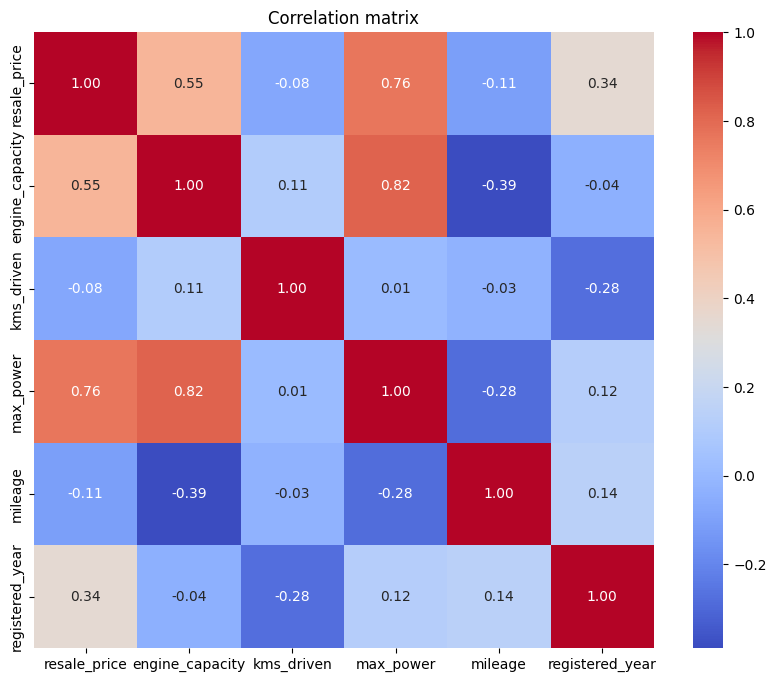

In [162]:
num_cols = ['resale_price', 'engine_capacity', 'kms_driven', 'max_power', 'mileage', 'registered_year']
plt.figure(figsize=(10, 8))
corr = fe_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation matrix")
plt.show()

Kết luận: 2 feature engine_capacity và max_power có tương quan cao -> gây đa cộng tuyến, loại engine_capacity vì correlation giữa engine_capacity và target (resale_price) là 0.76 cao hơn so với correlation giữa max_power và target.

In [163]:
fe_df.drop(columns=['engine_capacity'], inplace=True) 

2. Lọc top k features có MI cao nhất

In [164]:
# mutual information giữa các feature với target
X = fe_df.drop(columns=['resale_price'])
y = fe_df['resale_price']
mi_scores = mutual_info_regression(X, y, random_state=42)

mi_result = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_result)


                    Feature  MI Score
4                 max_power  0.894493
5                   mileage  0.583050
6           registered_year  0.393198
13           body_type_freq  0.270759
3                kms_driven  0.176552
0         transmission_type  0.167191
11         fuel_type_Diesel  0.082525
2                     seats  0.076715
12         fuel_type_Petrol  0.075904
7   insurance_Comprehensive  0.055273
1                owner_type  0.044985
9     insurance_Third Party  0.039071
10       insurance_Zero Dep  0.018906
8   insurance_Not Available  0.009626


Lấy những features có MI trên 0.1, nên loại các features: owner_type, seats.

In [165]:
fe_df.drop(columns=['owner_type', 'seats'], inplace=True)

#### 7.2.3 Feature Importance

In [166]:
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [167]:
X = fe_df.drop(columns=['resale_price'])
y = fe_df['resale_price']

In [168]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [169]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_importance)

                    Feature  Importance
2                 max_power    5.842575
4           registered_year    1.814897
3                   mileage    0.310767
1                kms_driven    0.087950
0         transmission_type    0.067821
11           body_type_freq    0.041187
9          fuel_type_Diesel    0.017885
10         fuel_type_Petrol    0.017063
7     insurance_Third Party    0.000598
8        insurance_Zero Dep    0.000245
6   insurance_Not Available   -0.000288
5   insurance_Comprehensive   -0.000465


#### 7.2.4 Recursive Feature Elimination (RFE)

In [170]:
rfe = RFE(
    estimator=model,
    n_features_to_select=8,
    step=1
)

rfe.fit(X_train, y_train)

# Feature được chọn
selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['transmission_type', 'kms_driven', 'max_power', 'mileage',
       'registered_year', 'fuel_type_Diesel', 'fuel_type_Petrol',
       'body_type_freq'],
      dtype='object')


**Kết luận:**

Những features chọn là: kms_driven, max_power, mileage, registered_year, transmission_type, body_type_freq, fuel_type_Diesel, fuel_type_Petrol.